# PLS Dimension Reduction (By Shot Location + Shot Type)

This notebook runs **Partial Least Squares (PLS)** as a supervised dimension-reduction method using `Made` (0/1) as the response.

## Pros of PLS
- Supervised components (uses `Made`, unlike PCA)
- Handles multicollinearity well
- Components can be inspected via weights / VIP

## Cons of PLS
- Components depend on the response choice
- Needs tuning for number of components
- For binary `Made`, PLS itself is regression; evaluate prediction out-of-sample

## Rules implemented
- Run for every `Shot.Location`
- Split by `Shot.Type` (Off the Dribble / Catch and Shoot) for all locations except Free Throw (combined)
- Drop players with < 20 shots per (location, type) subset
- Fit k=10 and k=20 PLS models (auto-reduced if not feasible)
- Exclude outcome-adjacent predictors: `Ball_Depth`, `Ball.Distance.from.Center`, and `b` (if present)

## How to tell if it predicts `Made` well
Component correlations (e.g., corr between `PLS3` and `Made`) are **not** enough. Use **out-of-sample** metrics.

This notebook reports cross-validated performance of:
`Impute -> Scale -> PLS(k) -> LogisticRegression`, with ROC AUC, Log Loss, Brier, Accuracy.

By default, CV uses `GroupKFold` grouped by `PlayerID` to measure generalization to **new players**. You can switch to `StratifiedKFold` via `CV_MODE`.


In [ ]:
from pathlib import Path
import sys
import importlib

for candidate in [Path.cwd(), Path.cwd() / "dimensional_reduction", Path.cwd().parent]:
    if (candidate / "pls_reduction_analysis.py").exists():
        sys.path.insert(0, str(candidate))
        break

import pls_reduction_analysis as pra
importlib.reload(pra)

RUN_CV_EVAL = True
CV_MAX_SPLITS = 5
CV_MODE = "group_by_player"
MIN_SHOTS_PER_PLAYER = 20
N_COMPONENTS = [10, 20]

EXCLUDE_NORM_KEYS = {"balldepth", "balldistancefromcenter", "b"}

DATA_PATH = Path("capstone2026.csv")
OUTPUT_DIR = Path("outputs")


**Loaded:** `capstone2026.csv`

**Excluded predictors found:** `['Ball_Depth', 'Ball.Distance.from.Center']`

**Numeric predictors used:** `254`

## Shot Location: Free Throw

### Shot Type: All

...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,-0.102291,0.102291,7.975381
1,PLS2,-0.094918,0.094918,15.809632
2,PLS1,-0.086882,0.086882,49.272857
3,PLS5,0.076559,0.076559,6.381468
4,PLS8,0.071751,0.071751,2.117871
5,PLS4,0.069540,0.069540,10.528906
6,PLS6,-0.063301,0.063301,6.253255
7,PLS10,-0.060896,0.060896,2.778992
8,PLS7,0.058111,0.058111,5.022738
9,PLS9,-0.051672,0.051672,4.413227


**Component definitions (exact weights) saved:** `outputs\pls_definition__free_throw__all__k10.csv`

**VIP scores saved:** `outputs\pls_vip__free_throw__all__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.240756
PostHitchZDelta,1.906228
PostHitchXDelta,1.752036
BallYHitch,1.587827
BallYRelease,1.578114
BallYPostHitch,1.566504
maxKneeExtensionRightPostHitch,1.519997
maxKneeExtensionAvgPostHitch,1.517157
BallZPostHitch,1.477103
maxShoulderExtensionRightPostHitch,1.456099


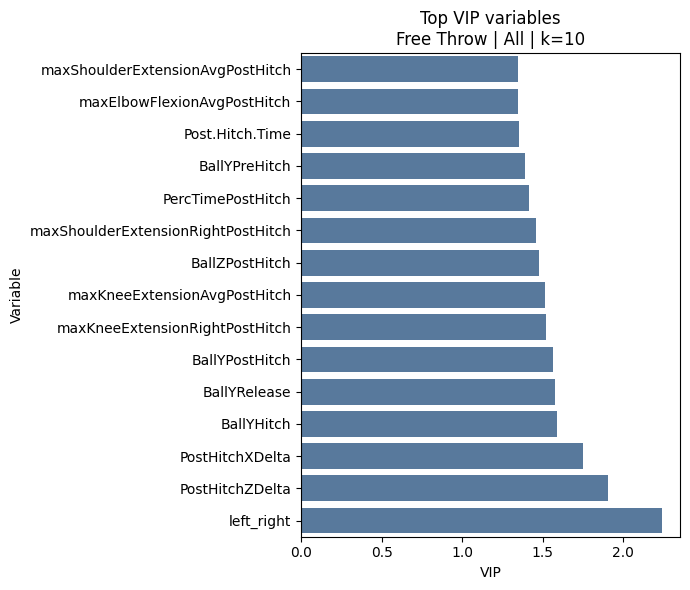

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallZRelease,0.128929,0.128929
1,Release.Height,0.128920,0.128920
2,timeToMaxElbowFlexionRightPreHitch,0.099837,-0.099837
3,timeToMaxKneeFlexionLeftHitch,0.099131,-0.099131
4,timeToMaxKneeExtensionLeftPostHitch,0.099076,-0.099076
5,timeToMaxKneeExtensionRightPostHitch,0.096703,-0.096703
6,timeToMaxHipFlexionRightHitch,0.096096,-0.096096
7,timeToMaxAnklePlantarflexionRightPostHitch,0.095350,-0.095350
8,timeToMaxHipFlexionLeftHitch,0.095219,-0.095219
9,timeToMaxAnklePlantarflexionLeftPostHitch,0.095116,-0.095116


- **PLS2**

,feature,abs_weight,PLS2
0,BallYHitch,0.158781,0.158781
1,BallYPostHitch,0.157807,0.157807
2,BallYRelease,0.152687,0.152687
3,left_right,0.138004,-0.138004
4,maxAnklePlantarflexionRightPreHitch,0.137053,-0.137053
5,TotalShotTime,0.132631,-0.132631
6,BallYPreHitch,0.126592,0.126592
7,maxHipExtensionLeftPostHitch,0.119309,-0.119309
8,PostHitchXDelta,0.114040,-0.114040
9,maxKneeFlexionLeftPostHitch,0.111983,0.111983


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,-0.102291,0.102291,7.975381
1,PLS2,-0.094918,0.094918,15.809632
2,PLS1,-0.086882,0.086882,49.272857
3,PLS5,0.076559,0.076559,6.381468
4,PLS8,0.071751,0.071751,2.117871
5,PLS4,0.069540,0.069540,10.528906
6,PLS6,-0.063301,0.063301,6.253255
7,PLS10,-0.060896,0.060896,2.778992
8,PLS7,0.058111,0.058111,5.022738
9,PLS9,-0.051672,0.051672,4.413227


**Component definitions (exact weights) saved:** `outputs\pls_definition__free_throw__all__k20.csv`

**VIP scores saved:** `outputs\pls_vip__free_throw__all__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.253969
PostHitchZDelta,1.771036
PostHitchXDelta,1.697430
BallYHitch,1.560109
BallYRelease,1.521918
BallYPostHitch,1.520307
maxKneeExtensionRightPostHitch,1.453104
maxKneeExtensionAvgPostHitch,1.443657
maxShoulderExtensionRightPostHitch,1.383919
BallZPostHitch,1.372387


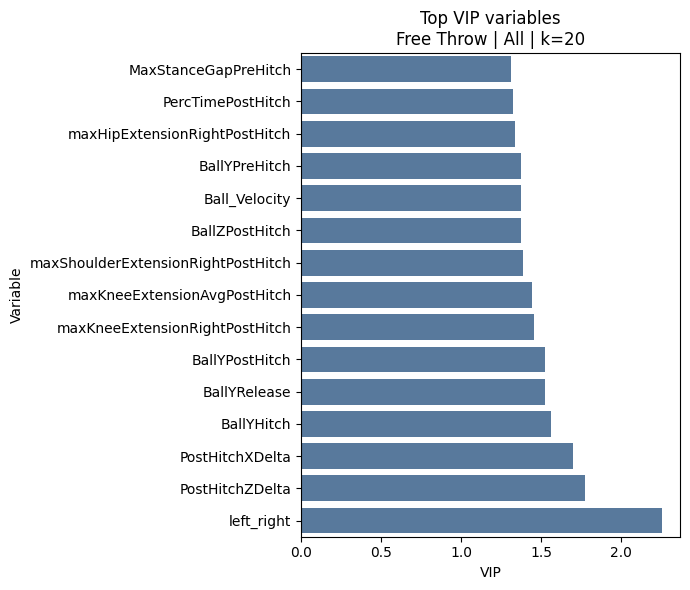

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallZRelease,0.128929,0.128929
1,Release.Height,0.128920,0.128920
2,timeToMaxElbowFlexionRightPreHitch,0.099837,-0.099837
3,timeToMaxKneeFlexionLeftHitch,0.099131,-0.099131
4,timeToMaxKneeExtensionLeftPostHitch,0.099076,-0.099076
5,timeToMaxKneeExtensionRightPostHitch,0.096703,-0.096703
6,timeToMaxHipFlexionRightHitch,0.096096,-0.096096
7,timeToMaxAnklePlantarflexionRightPostHitch,0.095350,-0.095350
8,timeToMaxHipFlexionLeftHitch,0.095219,-0.095219
9,timeToMaxAnklePlantarflexionLeftPostHitch,0.095116,-0.095116


- **PLS2**

,feature,abs_weight,PLS2
0,BallYHitch,0.158781,0.158781
1,BallYPostHitch,0.157807,0.157807
2,BallYRelease,0.152687,0.152687
3,left_right,0.138004,-0.138004
4,maxAnklePlantarflexionRightPreHitch,0.137053,-0.137053
5,TotalShotTime,0.132631,-0.132631
6,BallYPreHitch,0.126592,0.126592
7,maxHipExtensionLeftPostHitch,0.119309,-0.119309
8,PostHitchXDelta,0.114040,-0.114040
9,maxKneeFlexionLeftPostHitch,0.111983,0.111983


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,-0.167371,0.167371,8.632922
1,PLS1,0.161860,0.161860,41.305821
2,PLS2,0.147196,0.147196,21.024970
3,PLS6,-0.140242,0.140242,5.018237
4,PLS4,0.118486,0.118486,11.280295
5,PLS8,0.107463,0.107463,4.035121
6,PLS7,-0.104549,0.104549,4.250593
7,PLS5,0.102107,0.102107,10.049122
8,PLS9,0.096424,0.096424,4.589465
9,PLS10,-0.090164,0.090164,2.280311


**Component definitions (exact weights) saved:** `outputs\pls_definition__key__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__key__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
MaxStanceGapPostHitch,1.864285
MaxStanceGapRelease,1.730308
ShoulderFlexionAtT0Right,1.660858
timeAtRelease,1.489135
timeAtStartofHitch,1.488218
maxAnkleDorsiflexionRightHitch,1.485487
ShoulderFlexionAtT0Left,1.481319
maxAnklePlantarflexionLeftPreHitch,1.476235
timeAtEndofHitch,1.460551
ShoulderTotalROMRight,1.418472


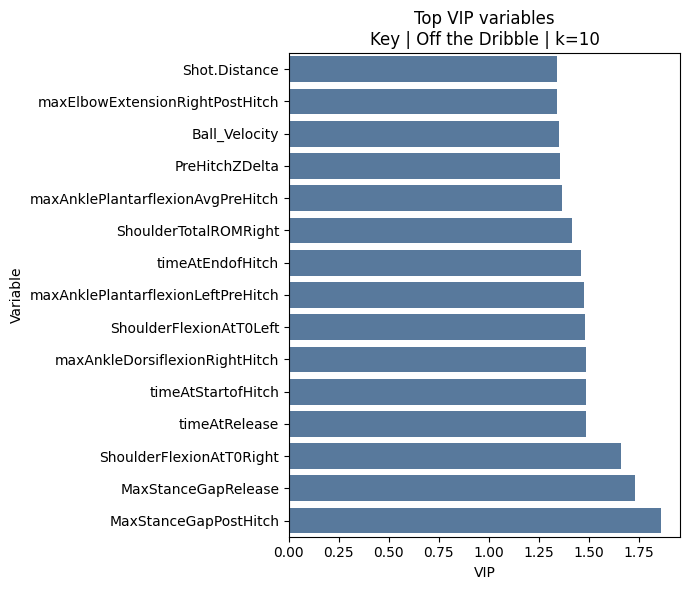

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxAnklePlantarflexionLeftHitch,0.142403,0.142403
1,MaxStanceGapPostHitch,0.129477,0.129477
2,maxAnklePlantarflexionAvgHitch,0.128565,0.128565
3,maxAnklePlantarflexionLeftPreHitch,0.128453,0.128453
4,maxAnkleDorsiflexionLeftPostHitch,0.127280,0.127280
5,HitchYDelta,0.125583,0.125583
6,BallVeloRelease,0.124663,0.124663
7,maxAnkleDorsiflexionAvgPostHitch,0.118345,0.118345
8,maxAnklePlantarflexionAvgPreHitch,0.117455,0.117455
9,timeAtStartofHitch,0.110974,0.110974


- **PLS2**

,feature,abs_weight,PLS2
0,MaxStanceGapPostHitch,0.153111,0.153111
1,timeAtStartofMovement,0.151248,0.151248
2,HitchYDelta,0.136608,0.136608
3,timeAtStartofHitch,0.121459,0.121459
4,timeAtRelease,0.118763,0.118763
5,PreHitchZDelta,0.115840,0.115840
6,maxAnklePlantarflexionLeftPreHitch,0.115020,0.115020
7,timeAtEndofHitch,0.113479,0.113479
8,maxAnklePlantarflexionLeftHitch,0.113094,0.113094
9,timeToMaxHipFlexionRightPreHitch,0.111089,-0.111089


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,-0.167371,0.167371,8.632922
1,PLS1,0.161860,0.161860,41.305821
2,PLS2,0.147196,0.147196,21.024970
3,PLS6,-0.140242,0.140242,5.018237
4,PLS4,0.118486,0.118486,11.280295
5,PLS8,0.107463,0.107463,4.035121
6,PLS7,-0.104549,0.104549,4.250593
7,PLS5,0.102107,0.102107,10.049122
8,PLS9,0.096424,0.096424,4.589465
9,PLS10,-0.090164,0.090164,2.280311


**Component definitions (exact weights) saved:** `outputs\pls_definition__key__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__key__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
MaxStanceGapPostHitch,1.778824
MaxStanceGapRelease,1.660394
ShoulderFlexionAtT0Right,1.632285
timeAtStartofHitch,1.530575
timeAtRelease,1.493959
maxElbowExtensionRightPostHitch,1.490437
timeAtEndofHitch,1.482427
ShoulderTotalROMRight,1.468546
HitchYDelta,1.461332
ShoulderFlexionAtT0Left,1.403916


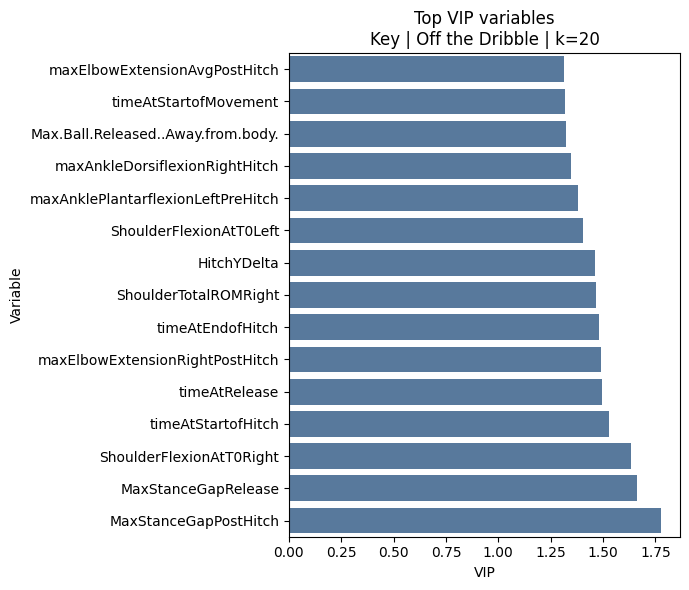

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxAnklePlantarflexionLeftHitch,0.142403,0.142403
1,MaxStanceGapPostHitch,0.129477,0.129477
2,maxAnklePlantarflexionAvgHitch,0.128565,0.128565
3,maxAnklePlantarflexionLeftPreHitch,0.128453,0.128453
4,maxAnkleDorsiflexionLeftPostHitch,0.127280,0.127280
5,HitchYDelta,0.125583,0.125583
6,BallVeloRelease,0.124663,0.124663
7,maxAnkleDorsiflexionAvgPostHitch,0.118345,0.118345
8,maxAnklePlantarflexionAvgPreHitch,0.117455,0.117455
9,timeAtStartofHitch,0.110974,0.110974


- **PLS2**

,feature,abs_weight,PLS2
0,MaxStanceGapPostHitch,0.153111,0.153111
1,timeAtStartofMovement,0.151248,0.151248
2,HitchYDelta,0.136608,0.136608
3,timeAtStartofHitch,0.121459,0.121459
4,timeAtRelease,0.118763,0.118763
5,PreHitchZDelta,0.115840,0.115840
6,maxAnklePlantarflexionLeftPreHitch,0.115020,0.115020
7,timeAtEndofHitch,0.113479,0.113479
8,maxAnklePlantarflexionLeftHitch,0.113094,0.113094
9,timeToMaxHipFlexionRightPreHitch,0.111089,-0.111089


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.216452,0.216452,24.076338
1,PLS5,-0.197452,0.197452,4.254898
2,PLS2,-0.179306,0.179306,22.295631
3,PLS4,-0.168857,0.168857,10.788138
4,PLS6,0.167293,0.167293,5.063962
5,PLS7,-0.152010,0.152010,5.165028
6,PLS3,-0.151362,0.151362,26.657418
7,PLS9,-0.141567,0.141567,4.357461
8,PLS10,0.122747,0.122747,3.056769
9,PLS8,-0.106095,0.106095,3.756177


**Component definitions (exact weights) saved:** `outputs\pls_definition__key__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__key__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,1.999285
BallVeloStart,1.735142
HitchYDelta,1.650855
Max.Ball.Released..Away.from.body.,1.461212
Max.Ball.Cocked,1.455225
maxShoulderFlexionLeftPostHitch,1.454451
maxElbowExtensionRightPostHitch,1.437333
maxTorsoFlexionPostHitch,1.392124
maxTorsoExtensionPostHitch,1.392124
ShoulderAlignmentHitch,1.390267


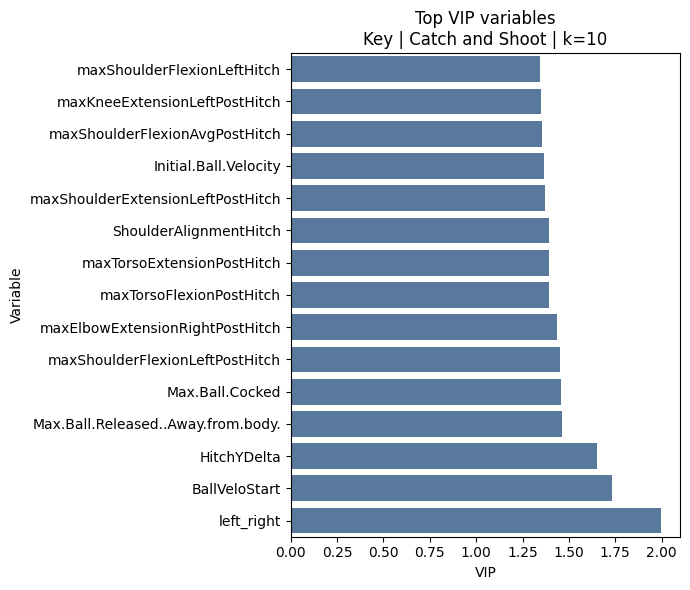

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderFlexionAvgHitch,0.161822,0.161822
1,maxShoulderFlexionAvgPostHitch,0.152699,0.152699
2,maxShoulderExtensionAvgPostHitch,0.152135,0.152135
3,maxShoulderFlexionLeftHitch,0.150856,0.150856
4,MaxStanceGapRelease,0.148253,0.148253
5,maxShoulderExtensionLeftPostHitch,0.140839,0.140839
6,maxShoulderFlexionRightHitch,0.137905,0.137905
7,BallZHitch,0.135413,0.135413
8,maxShoulderExtensionRightPostHitch,0.133977,0.133977
9,maxShoulderFlexionRightPostHitch,0.130082,0.130082


- **PLS2**

,feature,abs_weight,PLS2
0,timeToMaxKneeFlexionLeftPostHitch,0.138620,0.138620
1,timeToMaxKneeFlexionRightPostHitch,0.137922,0.137922
2,timeToMaxTorsoExtensionHitch,0.133962,0.133962
3,timeToMaxShoulderExtensionLeftHitch,0.131238,0.131238
4,left_right,0.129917,0.129917
5,timeToMaxHipFlexionRightPostHitch,0.128676,0.128676
6,BallVeloStart,0.128314,-0.128314
7,timeToMaxElbowExtensionRightPreHitch,0.126275,0.126275
8,timeToMaxKneeFlexionRightHitch,0.123372,0.123372
9,timeAtStartofHitch,0.119744,0.119744


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.216452,0.216452,24.076338
1,PLS5,-0.197452,0.197452,4.254898
2,PLS2,-0.179306,0.179306,22.295631
3,PLS4,-0.168857,0.168857,10.788138
4,PLS6,0.167293,0.167293,5.063962
5,PLS7,-0.152010,0.152010,5.165028
6,PLS3,-0.151362,0.151362,26.657418
7,PLS9,-0.141567,0.141567,4.357461
8,PLS12,-0.141066,0.141066,1.977923
9,PLS15,0.124017,0.124017,1.964179


**Component definitions (exact weights) saved:** `outputs\pls_definition__key__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__key__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,1.942763
BallVeloStart,1.742181
timeAtStartofHitch,1.514675
timeAtEndofHitch,1.510539
HitchYDelta,1.507818
timeAtRelease,1.507074
timeAtStartofMovement,1.476241
Max.Ball.Released..Away.from.body.,1.454143
maxShoulderFlexionLeftPostHitch,1.405661
maxTorsoFlexionPostHitch,1.404425


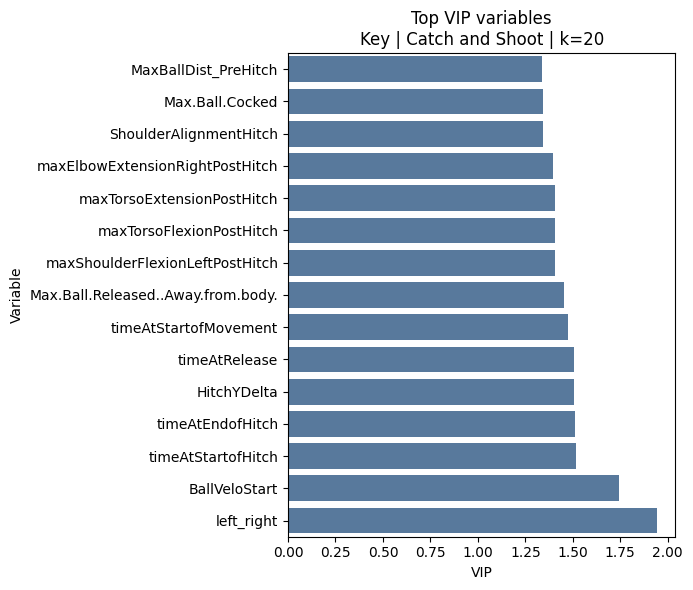

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderFlexionAvgHitch,0.161822,0.161822
1,maxShoulderFlexionAvgPostHitch,0.152699,0.152699
2,maxShoulderExtensionAvgPostHitch,0.152135,0.152135
3,maxShoulderFlexionLeftHitch,0.150856,0.150856
4,MaxStanceGapRelease,0.148253,0.148253
5,maxShoulderExtensionLeftPostHitch,0.140839,0.140839
6,maxShoulderFlexionRightHitch,0.137905,0.137905
7,BallZHitch,0.135413,0.135413
8,maxShoulderExtensionRightPostHitch,0.133977,0.133977
9,maxShoulderFlexionRightPostHitch,0.130082,0.130082


- **PLS2**

,feature,abs_weight,PLS2
0,timeToMaxKneeFlexionLeftPostHitch,0.138620,0.138620
1,timeToMaxKneeFlexionRightPostHitch,0.137922,0.137922
2,timeToMaxTorsoExtensionHitch,0.133962,0.133962
3,timeToMaxShoulderExtensionLeftHitch,0.131238,0.131238
4,left_right,0.129917,0.129917
5,timeToMaxHipFlexionRightPostHitch,0.128676,0.128676
6,BallVeloStart,0.128314,-0.128314
7,timeToMaxElbowExtensionRightPreHitch,0.126275,0.126275
8,timeToMaxKneeFlexionRightHitch,0.123372,0.123372
9,timeAtStartofHitch,0.119744,0.119744


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.108853,0.108853,5.368497
1,PLS2,0.107799,0.107799,22.202644
2,PLS4,0.091252,0.091252,5.563297
3,PLS1,-0.087472,0.087472,19.669215
4,PLS5,-0.075970,0.075970,7.023531
5,PLS6,0.062682,0.062682,6.155480
6,PLS7,-0.062639,0.062639,8.518958
7,PLS8,0.062637,0.062637,3.687388
8,PLS10,0.055875,0.055875,3.557383
9,PLS9,0.043094,0.043094,7.790938


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_three__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_three__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
Shot.X.Pos,2.397243
Shot.Distance,2.384960
left_right,2.378447
ElbowTotalROMRight,1.634612
Ball_to_Rim_Angle,1.621961
maxAnklePlantarflexionLeftPostHitch,1.577976
maxElbowExtensionRightPostHitch,1.571349
maxAnklePlantarflexionAvgPostHitch,1.535111
maxAnklePlantarflexionRightPostHitch,1.508334
maxAnkleDorsiflexionRightHitch,1.489290


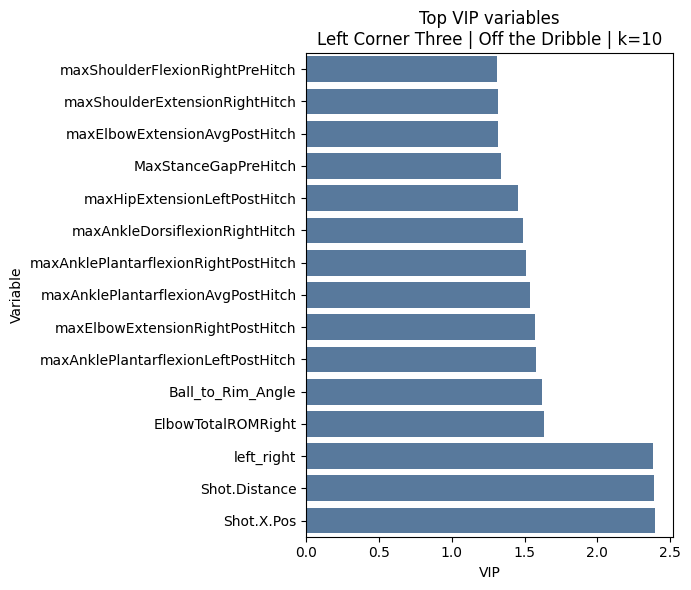

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Shot.Distance,0.263223,0.263223
1,Shot.X.Pos,0.261022,-0.261022
2,left_right,0.169411,0.169411
3,maxHipExtensionLeftPostHitch,0.152597,-0.152597
4,MaxStanceGapPreHitch,0.151372,0.151372
5,maxAnklePlantarflexionRightPostHitch,0.146808,0.146808
6,HitchYDelta,0.131112,-0.131112
7,maxAnklePlantarflexionAvgPostHitch,0.130100,0.130100
8,maxElbowExtensionRightHitch,0.120506,-0.120506
9,maxHipExtensionAvgPostHitch,0.113952,-0.113952


- **PLS2**

,feature,abs_weight,PLS2
0,Shot.X.Pos,0.184802,0.184802
1,Shot.Distance,0.183751,-0.183751
2,timeToMaxShoulderExtensionLeftPreHitch,0.124682,0.124682
3,left_right,0.117905,-0.117905
4,timeToMaxShoulderExtensionRightPreHitch,0.117855,0.117855
5,timeToMaxElbowFlexionRightPreHitch,0.116452,0.116452
6,timeToMaxTorsoFlexionPostHitch,0.110982,0.110982
7,timeToMaxTorsoExtensionPostHitch,0.110982,0.110982
8,timeToMaxHipFlexionLeftPostHitch,0.110014,0.110014
9,timeToMaxHipFlexionLeftPreHitch,0.109500,0.109500


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.108853,0.108853,5.368497
1,PLS2,0.107799,0.107799,22.202644
2,PLS4,0.091252,0.091252,5.563297
3,PLS1,-0.087472,0.087472,19.669215
4,PLS5,-0.075970,0.075970,7.023531
5,PLS6,0.062682,0.062682,6.155480
6,PLS7,-0.062639,0.062639,8.518958
7,PLS8,0.062637,0.062637,3.687388
8,PLS10,0.055875,0.055875,3.557383
9,PLS15,-0.051700,0.051700,1.907180


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_three__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_three__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.279412
Shot.X.Pos,2.138995
Shot.Distance,2.115847
Ball_to_Rim_Angle,1.525727
ElbowTotalROMRight,1.487368
maxAnklePlantarflexionLeftPostHitch,1.485374
maxElbowExtensionRightPostHitch,1.479005
maxAnkleDorsiflexionRightHitch,1.460713
maxAnklePlantarflexionAvgPostHitch,1.450694
maxAnklePlantarflexionRightPostHitch,1.424193


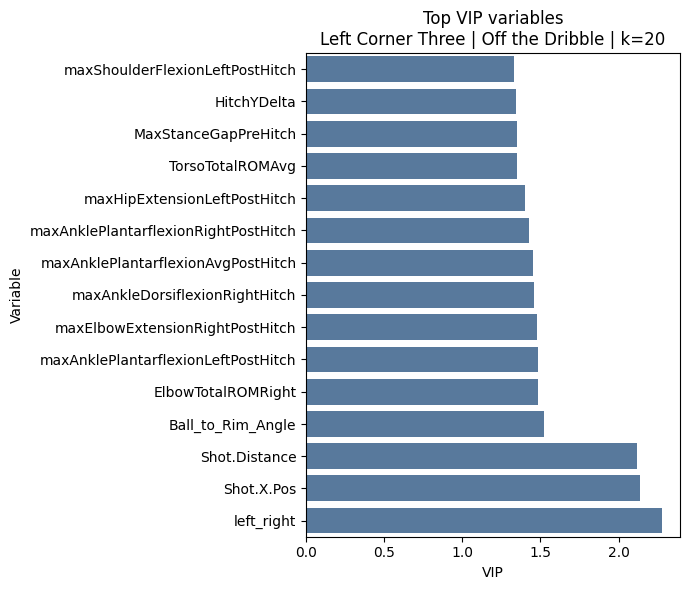

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Shot.Distance,0.263223,0.263223
1,Shot.X.Pos,0.261022,-0.261022
2,left_right,0.169411,0.169411
3,maxHipExtensionLeftPostHitch,0.152597,-0.152597
4,MaxStanceGapPreHitch,0.151372,0.151372
5,maxAnklePlantarflexionRightPostHitch,0.146808,0.146808
6,HitchYDelta,0.131112,-0.131112
7,maxAnklePlantarflexionAvgPostHitch,0.130100,0.130100
8,maxElbowExtensionRightHitch,0.120506,-0.120506
9,maxHipExtensionAvgPostHitch,0.113952,-0.113952


- **PLS2**

,feature,abs_weight,PLS2
0,Shot.X.Pos,0.184802,0.184802
1,Shot.Distance,0.183751,-0.183751
2,timeToMaxShoulderExtensionLeftPreHitch,0.124682,0.124682
3,left_right,0.117905,-0.117905
4,timeToMaxShoulderExtensionRightPreHitch,0.117855,0.117855
5,timeToMaxElbowFlexionRightPreHitch,0.116452,0.116452
6,timeToMaxTorsoFlexionPostHitch,0.110982,0.110982
7,timeToMaxTorsoExtensionPostHitch,0.110982,0.110982
8,timeToMaxHipFlexionLeftPostHitch,0.110014,0.110014
9,timeToMaxHipFlexionLeftPreHitch,0.109500,0.109500


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.210204,0.210204,10.894206
1,PLS5,0.188659,0.188659,8.007669
2,PLS1,0.175437,0.175437,32.153083
3,PLS7,-0.170039,0.170039,3.501255
4,PLS6,-0.162358,0.162358,3.599491
5,PLS2,0.159629,0.159629,13.771635
6,PLS4,-0.157461,0.157461,16.443956
7,PLS9,-0.121380,0.121380,4.676562
8,PLS10,0.118729,0.118729,3.592047
9,PLS8,-0.095820,0.095820,6.415647


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_three__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_three__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
Ball_to_Rim_Angle,1.769455
Shot.X.Pos,1.707359
TorsoVeloHitch,1.703323
Initial.Ball.Velocity,1.665809
Initial.Ball.Angle,1.640082
Shot.Distance,1.621540
BallVeloRelease,1.607190
FeetAlignmentPostHitch,1.501538
hipTotalROMLeft,1.381740
maxShoulderFlexionAvgPreHitch,1.357229


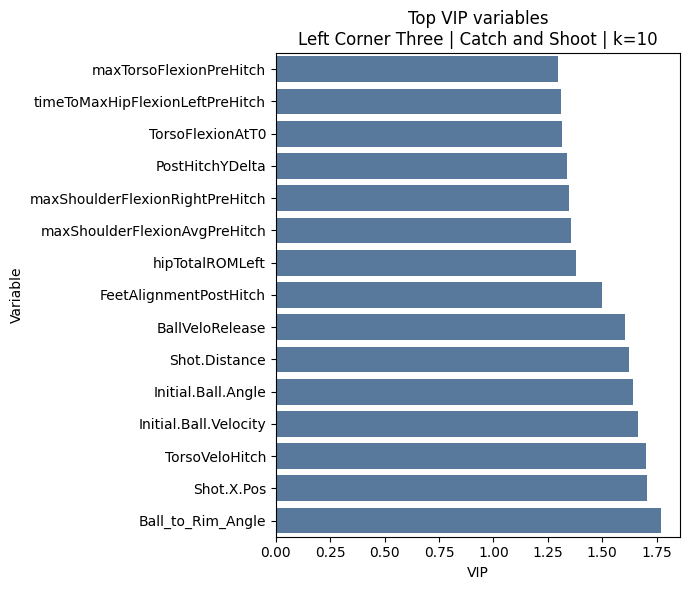

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderFlexionAvgHitch,0.150107,0.150107
1,maxShoulderFlexionRightHitch,0.149446,0.149446
2,maxShoulderExtensionRightHitch,0.139821,0.139821
3,maxShoulderExtensionRightPostHitch,0.135581,0.135581
4,maxShoulderExtensionAvgPostHitch,0.134511,0.134511
5,maxShoulderFlexionRightPreHitch,0.132287,0.132287
6,timeToMaxShoulderExtensionRightPostHitch,0.126215,0.126215
7,maxAnkleDorsiflexionRightPreHitch,0.125196,-0.125196
8,maxShoulderFlexionLeftHitch,0.119254,0.119254
9,maxShoulderExtensionAvgHitch,0.117047,0.117047


- **PLS2**

,feature,abs_weight,PLS2
0,Shot.X.Pos,0.176802,0.176802
1,FeetAlignmentPostHitch,0.174548,-0.174548
2,Shot.Distance,0.169049,-0.169049
3,Initial.Ball.Velocity,0.160882,0.160882
4,BallVeloRelease,0.157748,0.157748
5,timeToMaxHipFlexionLeftPreHitch,0.144292,-0.144292
6,maxElbowExtensionAvgPreHitch,0.134433,-0.134433
7,TorsoVeloHitch,0.132202,-0.132202
8,maxElbowExtensionLeftPreHitch,0.127332,-0.127332
9,maxTorsoExtensionPostHitch,0.122085,-0.122085


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.210204,0.210204,10.894206
1,PLS5,0.188659,0.188659,8.007669
2,PLS1,0.175437,0.175437,32.153083
3,PLS7,-0.170039,0.170039,3.501255
4,PLS6,-0.162358,0.162358,3.599491
5,PLS2,0.159629,0.159629,13.771635
6,PLS4,-0.157461,0.157461,16.443956
7,PLS14,-0.121844,0.121844,2.969097
8,PLS9,-0.121380,0.121380,4.676562
9,PLS10,0.118729,0.118729,3.592047


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_three__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_three__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
TorsoVeloHitch,1.706908
Ball_to_Rim_Angle,1.641041
Shot.X.Pos,1.619022
Initial.Ball.Angle,1.575477
Shot.Distance,1.555984
BallVeloRelease,1.513274
Max.Ball.Arc,1.495680
Initial.Ball.Velocity,1.494022
FeetAlignmentPostHitch,1.368175
ankleFlexionAtT0Avg,1.359333


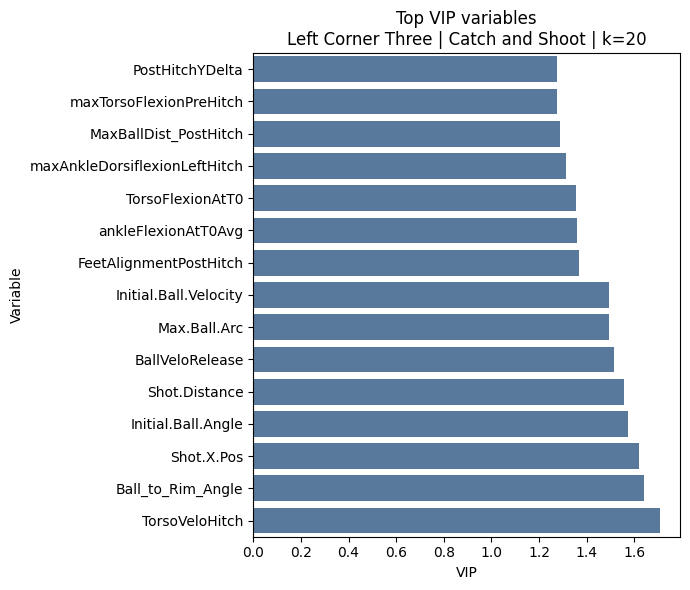

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderFlexionAvgHitch,0.150107,0.150107
1,maxShoulderFlexionRightHitch,0.149446,0.149446
2,maxShoulderExtensionRightHitch,0.139821,0.139821
3,maxShoulderExtensionRightPostHitch,0.135581,0.135581
4,maxShoulderExtensionAvgPostHitch,0.134511,0.134511
5,maxShoulderFlexionRightPreHitch,0.132287,0.132287
6,timeToMaxShoulderExtensionRightPostHitch,0.126215,0.126215
7,maxAnkleDorsiflexionRightPreHitch,0.125196,-0.125196
8,maxShoulderFlexionLeftHitch,0.119254,0.119254
9,maxShoulderExtensionAvgHitch,0.117047,0.117047


- **PLS2**

,feature,abs_weight,PLS2
0,Shot.X.Pos,0.176802,0.176802
1,FeetAlignmentPostHitch,0.174548,-0.174548
2,Shot.Distance,0.169049,-0.169049
3,Initial.Ball.Velocity,0.160882,0.160882
4,BallVeloRelease,0.157748,0.157748
5,timeToMaxHipFlexionLeftPreHitch,0.144292,-0.144292
6,maxElbowExtensionAvgPreHitch,0.134433,-0.134433
7,TorsoVeloHitch,0.132202,-0.132202
8,maxElbowExtensionLeftPreHitch,0.127332,-0.127332
9,maxTorsoExtensionPostHitch,0.122085,-0.122085


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS4,0.327566,0.327566,11.321328
1,PLS6,-0.279594,0.279594,2.495383
2,PLS3,0.277071,0.277071,17.975331
3,PLS9,0.272464,0.272464,1.000651
4,PLS1,0.251984,0.251984,77.097589
5,PLS7,0.247938,0.247938,3.008838
6,PLS10,0.244349,0.244349,1.935218
7,PLS8,0.231599,0.231599,3.151081
8,PLS2,-0.229117,0.229117,20.537406
9,PLS5,0.173066,0.173066,14.017771


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_two__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_two__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.263570
Ball_to_Rim_Angle,2.051598
Initial.Ball.Angle,1.913322
maxTorsoExtensionHitch,1.717893
TorsoTotalROMAvg,1.573104
MaxStanceGapPreHitch,1.538947
maxHipExtensionLeftPostHitch,1.534331
maxTorsoExtensionPostHitch,1.532894
maxTorsoFlexionPostHitch,1.532894
maxHipFlexionLeftPreHitch,1.514870


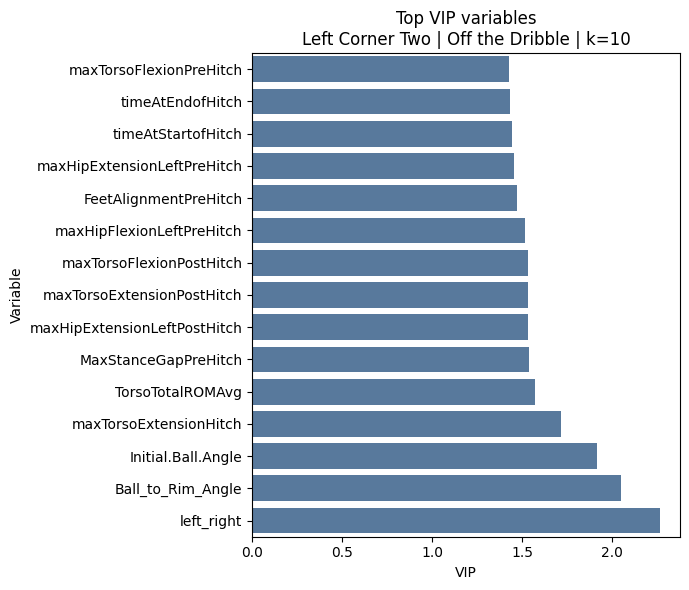

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Ball_to_Rim_Angle,0.154851,0.154851
1,Initial.Ball.Angle,0.137142,0.137142
2,PercTimeHitch,0.132907,0.132907
3,Ball_Velocity,0.115022,-0.115022
4,maxShoulderFlexionLeftPostHitch,0.113174,0.113174
5,maxShoulderFlexionAvgPostHitch,0.111069,0.111069
6,ankleFlexionAtT0Avg,0.098777,0.098777
7,timeToMaxTorsoFlexionPostHitch,0.096427,0.096427
8,timeToMaxTorsoExtensionPostHitch,0.096427,0.096427
9,maxAnkleDorsiflexionLeftPostHitch,0.095903,-0.095903


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.204105,0.204105
1,PreHitchXDelta,0.195750,-0.195750
2,Ball_to_Rim_Angle,0.181131,-0.181131
3,Initial.Ball.Angle,0.169149,-0.169149
4,maxShoulderExtensionLeftPostHitch,0.153568,-0.153568
5,maxShoulderFlexionLeftHitch,0.147379,-0.147379
6,maxTorsoFlexionPreHitch,0.138200,-0.138200
7,MaxStanceGapPreHitch,0.129482,0.129482
8,ShoulderAlignmentPreHitch,0.127907,-0.127907
9,PreHitchZDelta,0.120352,0.120352


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS4,0.327566,0.327566,11.321328
1,PLS6,-0.279594,0.279594,2.495383
2,PLS3,0.277071,0.277071,17.975331
3,PLS9,0.272464,0.272464,1.000651
4,PLS1,0.251984,0.251984,77.097589
5,PLS7,0.247938,0.247938,3.008838
6,PLS10,0.244349,0.244349,1.935218
7,PLS8,0.231599,0.231599,3.151081
8,PLS2,-0.229117,0.229117,20.537406
9,PLS14,-0.207118,0.207118,0.702041


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_two__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_two__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.487192
FeetAlignmentRelease,1.933240
Ball_to_Rim_Angle,1.918377
maxTorsoExtensionHitch,1.839786
Initial.Ball.Angle,1.809605
TorsoVeloHitch,1.690070
maxTorsoExtensionPreHitch,1.645690
maxTorsoFlexionPostHitch,1.637292
maxTorsoExtensionPostHitch,1.637292
maxTorsoFlexionPreHitch,1.619799


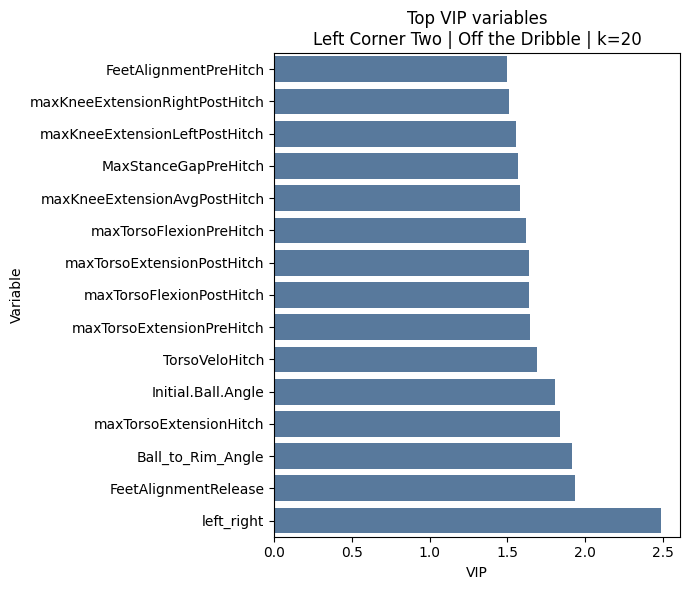

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Ball_to_Rim_Angle,0.154851,0.154851
1,Initial.Ball.Angle,0.137142,0.137142
2,PercTimeHitch,0.132907,0.132907
3,Ball_Velocity,0.115022,-0.115022
4,maxShoulderFlexionLeftPostHitch,0.113174,0.113174
5,maxShoulderFlexionAvgPostHitch,0.111069,0.111069
6,ankleFlexionAtT0Avg,0.098777,0.098777
7,timeToMaxTorsoFlexionPostHitch,0.096427,0.096427
8,timeToMaxTorsoExtensionPostHitch,0.096427,0.096427
9,maxAnkleDorsiflexionLeftPostHitch,0.095903,-0.095903


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.204105,0.204105
1,PreHitchXDelta,0.195750,-0.195750
2,Ball_to_Rim_Angle,0.181131,-0.181131
3,Initial.Ball.Angle,0.169149,-0.169149
4,maxShoulderExtensionLeftPostHitch,0.153568,-0.153568
5,maxShoulderFlexionLeftHitch,0.147379,-0.147379
6,maxTorsoFlexionPreHitch,0.138200,-0.138200
7,MaxStanceGapPreHitch,0.129482,0.129482
8,ShoulderAlignmentPreHitch,0.127907,-0.127907
9,PreHitchZDelta,0.120352,0.120352


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.417429,0.417429,13.683050
1,PLS5,-0.369250,0.369250,4.076846
2,PLS4,-0.329158,0.329158,9.525345
3,PLS7,-0.322682,0.322682,4.558995
4,PLS6,0.287534,0.287534,4.616969
5,PLS2,0.263206,0.263206,21.684888
6,PLS1,0.252114,0.252114,62.812329
7,PLS9,-0.199248,0.199248,2.620462
8,PLS8,-0.186254,0.186254,3.355849
9,PLS10,-0.153237,0.153237,3.319768


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_two__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_two__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
TorsoVeloRelease,2.331712
Initial.Ball.Velocity,1.989856
FeetAlignmentPostHitch,1.809261
BallXPreHitch,1.702511
Shot.Distance,1.682025
Shot.X.Pos,1.681251
ElbowTotalROMRight,1.676082
BallXRelease,1.672461
BallVeloRelease,1.657595
Pass.Direction,1.648373


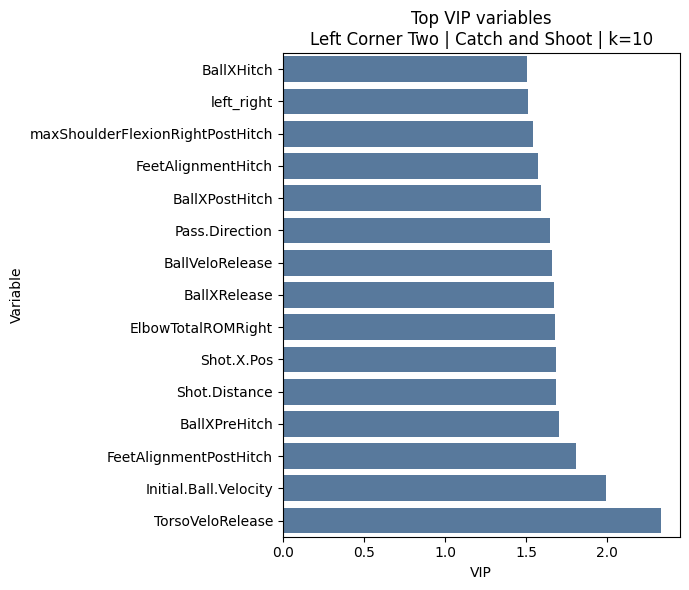

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Initial.Ball.Velocity,0.160987,0.160987
1,maxElbowExtensionLeftPreHitch,0.114723,0.114723
2,Pass.Direction,0.114488,0.114488
3,Max.Ball.Released..Away.from.body.,0.112518,-0.112518
4,maxElbowFlexionLeftPreHitch,0.111357,0.111357
5,left_right,0.111167,0.111167
6,FeetAlignmentHitch,0.107629,0.107629
7,maxAnklePlantarflexionRightPostHitch,0.104690,-0.104690
8,maxElbowExtensionAvgPreHitch,0.102304,0.102304
9,maxHipExtensionLeftHitch,0.099459,0.099459


- **PLS2**

,feature,abs_weight,PLS2
0,Initial.Ball.Velocity,0.245340,0.245340
1,Ball_Velocity,0.180680,0.180680
2,FeetAlignmentHitch,0.173137,0.173137
3,ankleFlexionAtT0Avg,0.159603,-0.159603
4,maxHipExtensionLeftPostHitch,0.154788,0.154788
5,Max.Ball.Cocked,0.134750,-0.134750
6,maxAnklePlantarflexionRightHitch,0.132951,-0.132951
7,PostHitchYDelta,0.131874,0.131874
8,ShoulderAlignmentRelease,0.129667,0.129667
9,timeToMaxElbowFlexionLeftPreHitch,0.129667,-0.129667


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.417429,0.417429,13.683050
1,PLS5,-0.369250,0.369250,4.076846
2,PLS4,-0.329158,0.329158,9.525345
3,PLS7,-0.322682,0.322682,4.558995
4,PLS6,0.287534,0.287534,4.616969
5,PLS2,0.263206,0.263206,21.684888
6,PLS1,0.252114,0.252114,62.812329
7,PLS11,-0.206235,0.206235,1.163227
8,PLS9,-0.199248,0.199248,2.620462
9,PLS8,-0.186254,0.186254,3.355849


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_corner_two__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_corner_two__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
TorsoVeloRelease,2.183810
Initial.Ball.Velocity,1.875103
FeetAlignmentPostHitch,1.737302
ElbowTotalROMRight,1.685252
FeetAlignmentHitch,1.656588
BallVeloRelease,1.599548
Pass.Direction,1.594203
Shot.Distance,1.584047
Shot.X.Pos,1.583946
BallXPreHitch,1.578941


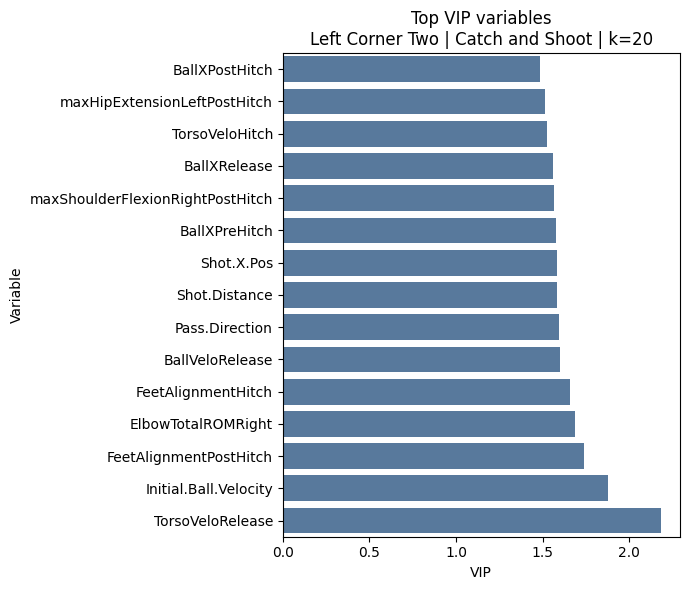

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Initial.Ball.Velocity,0.160987,0.160987
1,maxElbowExtensionLeftPreHitch,0.114723,0.114723
2,Pass.Direction,0.114488,0.114488
3,Max.Ball.Released..Away.from.body.,0.112518,-0.112518
4,maxElbowFlexionLeftPreHitch,0.111357,0.111357
5,left_right,0.111167,0.111167
6,FeetAlignmentHitch,0.107629,0.107629
7,maxAnklePlantarflexionRightPostHitch,0.104690,-0.104690
8,maxElbowExtensionAvgPreHitch,0.102304,0.102304
9,maxHipExtensionLeftHitch,0.099459,0.099459


- **PLS2**

,feature,abs_weight,PLS2
0,Initial.Ball.Velocity,0.245340,0.245340
1,Ball_Velocity,0.180680,0.180680
2,FeetAlignmentHitch,0.173137,0.173137
3,ankleFlexionAtT0Avg,0.159603,-0.159603
4,maxHipExtensionLeftPostHitch,0.154788,0.154788
5,Max.Ball.Cocked,0.134750,-0.134750
6,maxAnklePlantarflexionRightHitch,0.132951,-0.132951
7,PostHitchYDelta,0.131874,0.131874
8,ShoulderAlignmentRelease,0.129667,0.129667
9,timeToMaxElbowFlexionLeftPreHitch,0.129667,-0.129667


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.182191,0.182191,18.081267
1,PLS3,-0.179787,0.179787,14.235519
2,PLS5,-0.174647,0.174647,6.110264
3,PLS2,-0.163331,0.163331,32.024305
4,PLS6,-0.156620,0.156620,4.935649
5,PLS4,-0.143045,0.143045,11.092553
6,PLS9,0.139363,0.139363,3.283305
7,PLS10,-0.130439,0.130439,2.193539
8,PLS8,0.118071,0.118071,6.847187
9,PLS7,0.117929,0.117929,7.738985


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_wing_three__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_wing_three__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
maxTorsoFlexionHitch,1.830273
FeetAlignmentHitch,1.771877
maxHipExtensionLeftPostHitch,1.652359
MaxStanceGapPostHitch,1.641013
maxKneeExtensionLeftPreHitch,1.628877
maxHipExtensionAvgPostHitch,1.389463
maxKneeExtensionAvgPreHitch,1.386888
maxHipExtensionRightPostHitch,1.374842
maxAnkleDorsiflexionLeftPreHitch,1.373899
maxKneeExtensionLeftPostHitch,1.359483


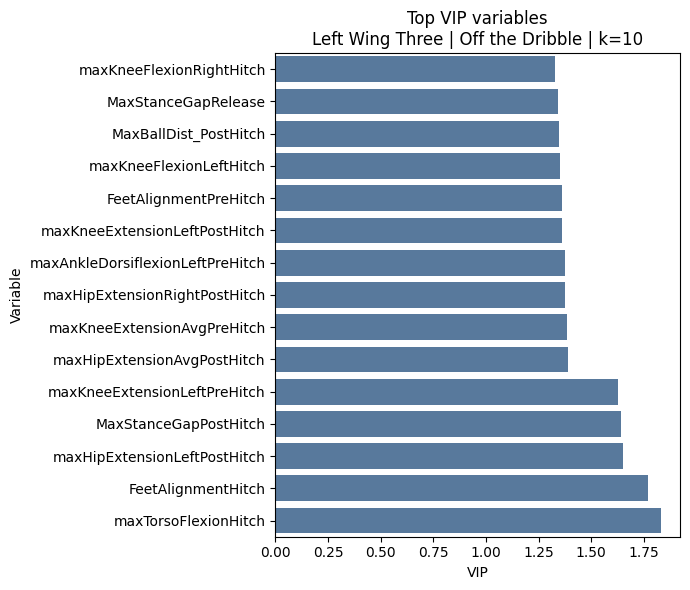

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxElbowFlexionAvgPostHitch,0.166854,0.166854
1,maxElbowFlexionAvgHitch,0.161598,0.161598
2,Shot.Distance,0.159369,-0.159369
3,BallXPreHitch,0.151770,0.151770
4,maxElbowExtensionAvgHitch,0.150148,0.150148
5,BallXPostHitch,0.147468,0.147468
6,BallXRelease,0.145514,0.145514
7,BallXHitch,0.145157,0.145157
8,PostHitchXDelta,0.141127,-0.141127
9,BallYHitch,0.139561,-0.139561


- **PLS2**

,feature,abs_weight,PLS2
0,timeToMaxAnklePlantarflexionRightPostHitch,0.142918,0.142918
1,timeToMaxKneeFlexionLeftPreHitch,0.127055,0.127055
2,timeToMaxKneeExtensionLeftPostHitch,0.126848,0.126848
3,timeToMaxKneeFlexionLeftHitch,0.125197,0.125197
4,timeToMaxKneeExtensionRightPostHitch,0.124114,0.124114
5,timeToMaxShoulderExtensionLeftPostHitch,0.123969,0.123969
6,timeToMaxShoulderExtensionRightPostHitch,0.123065,0.123065
7,timeToMaxHipExtensionRightPostHitch,0.121056,0.121056
8,timeToMaxAnkleDorsiflexionLeftHitch,0.119623,0.119623
9,timeToMaxAnkleDorsiflexionRightHitch,0.119471,0.119471


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.182191,0.182191,18.081267
1,PLS3,-0.179787,0.179787,14.235519
2,PLS5,-0.174647,0.174647,6.110264
3,PLS2,-0.163331,0.163331,32.024305
4,PLS6,-0.156620,0.156620,4.935649
5,PLS4,-0.143045,0.143045,11.092553
6,PLS9,0.139363,0.139363,3.283305
7,PLS10,-0.130439,0.130439,2.193539
8,PLS8,0.118071,0.118071,6.847187
9,PLS7,0.117929,0.117929,7.738985


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_wing_three__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_wing_three__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
maxTorsoFlexionHitch,1.815358
FeetAlignmentPreHitch,1.640658
maxKneeExtensionLeftPreHitch,1.594920
FeetAlignmentHitch,1.592106
maxHipExtensionLeftPostHitch,1.485382
maxTorsoFlexionPreHitch,1.483259
MaxStanceGapPostHitch,1.456640
Max.Ball.Arc,1.443166
TorsoFlexionAtT0,1.417167
MaxBallDist_PostHitch,1.399740


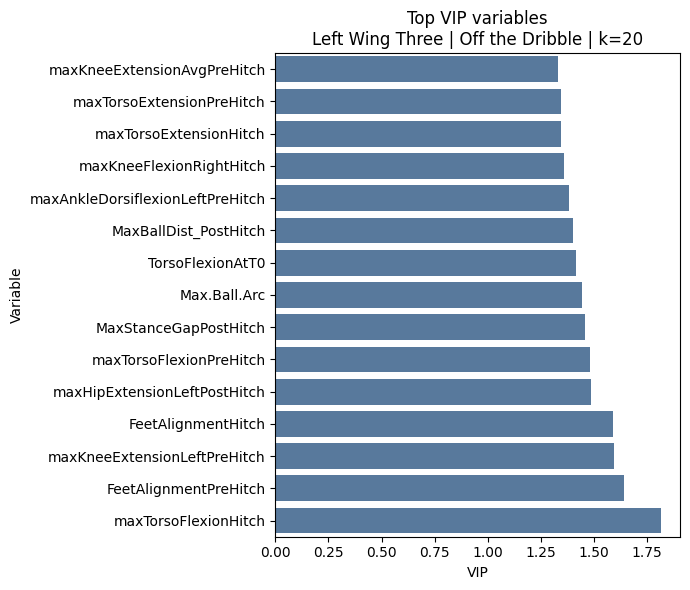

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxElbowFlexionAvgPostHitch,0.166854,0.166854
1,maxElbowFlexionAvgHitch,0.161598,0.161598
2,Shot.Distance,0.159369,-0.159369
3,BallXPreHitch,0.151770,0.151770
4,maxElbowExtensionAvgHitch,0.150148,0.150148
5,BallXPostHitch,0.147468,0.147468
6,BallXRelease,0.145514,0.145514
7,BallXHitch,0.145157,0.145157
8,PostHitchXDelta,0.141127,-0.141127
9,BallYHitch,0.139561,-0.139561


- **PLS2**

,feature,abs_weight,PLS2
0,timeToMaxAnklePlantarflexionRightPostHitch,0.142918,0.142918
1,timeToMaxKneeFlexionLeftPreHitch,0.127055,0.127055
2,timeToMaxKneeExtensionLeftPostHitch,0.126848,0.126848
3,timeToMaxKneeFlexionLeftHitch,0.125197,0.125197
4,timeToMaxKneeExtensionRightPostHitch,0.124114,0.124114
5,timeToMaxShoulderExtensionLeftPostHitch,0.123969,0.123969
6,timeToMaxShoulderExtensionRightPostHitch,0.123065,0.123065
7,timeToMaxHipExtensionRightPostHitch,0.121056,0.121056
8,timeToMaxAnkleDorsiflexionLeftHitch,0.119623,0.119623
9,timeToMaxAnkleDorsiflexionRightHitch,0.119471,0.119471


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS4,0.148307,0.148307,4.373215
1,PLS3,0.142612,0.142612,14.972414
2,PLS1,0.138157,0.138157,10.292602
3,PLS5,-0.111714,0.111714,6.023141
4,PLS7,-0.111285,0.111285,7.039527
5,PLS9,-0.111155,0.111155,3.730965
6,PLS8,0.100062,0.100062,4.695391
7,PLS6,0.095318,0.095318,6.415846
8,PLS2,0.088793,0.088793,28.873932
9,PLS10,-0.088032,0.088032,2.724996


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_wing_three__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_wing_three__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
Initial.Ball.Velocity,2.075015
Max.Ball.Arc,1.737305
BallVeloRelease,1.714692
Delta.Ball.Cocked.vs.Release,1.693593
Max.Ball.Released..Away.from.body.,1.662354
MaxBallDist_PreHitch,1.568939
maxShoulderFlexionLeftPostHitch,1.467743
maxElbowExtensionLeftPreHitch,1.435178
FeetAlignmentRelease,1.432617
maxAnklePlantarflexionLeftPostHitch,1.431866


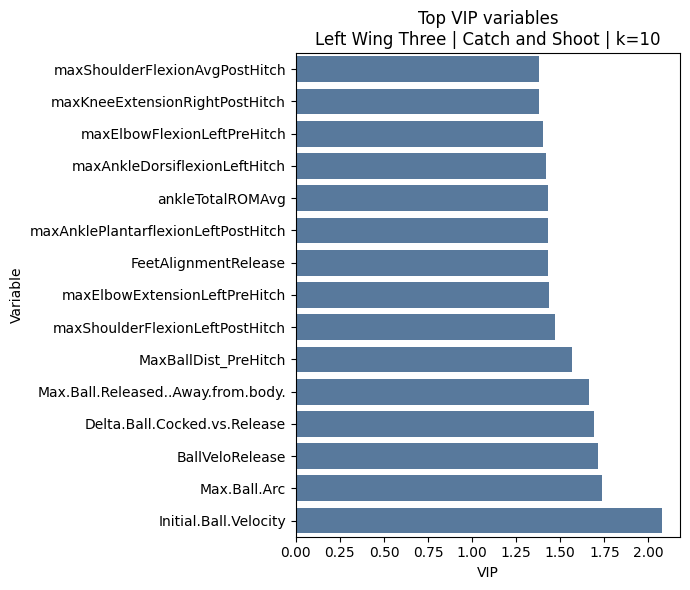

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Initial.Ball.Velocity,0.244458,0.244458
1,Delta.Ball.Cocked.vs.Release,0.225272,-0.225272
2,Max.Ball.Released..Away.from.body.,0.198297,-0.198297
3,Max.Ball.Arc,0.186750,0.186750
4,MaxBallDist_PreHitch,0.175752,-0.175752
5,FeetAlignmentRelease,0.157697,0.157697
6,maxAnklePlantarflexionLeftPostHitch,0.153144,-0.153144
7,PreHitchYDelta,0.153091,-0.153091
8,maxAnklePlantarflexionLeftPreHitch,0.145731,-0.145731
9,maxAnkleDorsiflexionLeftPreHitch,0.143557,-0.143557


- **PLS2**

,feature,abs_weight,PLS2
0,Initial.Ball.Velocity,0.183809,0.183809
1,Delta.Ball.Cocked.vs.Release,0.146946,-0.146946
2,maxAnklePlantarflexionRightPreHitch,0.138049,0.138049
3,maxAnkleDorsiflexionRightPreHitch,0.133536,0.133536
4,Max.Ball.Arc,0.126638,0.126638
5,maxElbowExtensionAvgPostHitch,0.123766,-0.123766
6,maxKneeExtensionAvgPreHitch,0.122677,-0.122677
7,maxElbowFlexionAvgPostHitch,0.122414,-0.122414
8,BallVeloRelease,0.114931,0.114931
9,TorsoVeloPreHitch,0.113923,-0.113923


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS4,0.148307,0.148307,4.373215
1,PLS3,0.142612,0.142612,14.972414
2,PLS1,0.138157,0.138157,10.292602
3,PLS5,-0.111714,0.111714,6.023141
4,PLS7,-0.111285,0.111285,7.039527
5,PLS9,-0.111155,0.111155,3.730965
6,PLS12,0.102972,0.102972,2.224907
7,PLS8,0.100062,0.100062,4.695391
8,PLS14,-0.096250,0.096250,1.931479
9,PLS6,0.095318,0.095318,6.415846


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_wing_three__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_wing_three__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
Initial.Ball.Velocity,1.910389
Max.Ball.Arc,1.900900
BallVeloRelease,1.780512
FeetAlignmentPreHitch,1.558961
FeetAlignmentRelease,1.475496
Max.Ball.Released..Away.from.body.,1.471196
ankleTotalROMAvg,1.466775
Delta.Ball.Cocked.vs.Release,1.448826
HipAlignmentPreHitch,1.409675
maxHipExtensionLeftPostHitch,1.394384


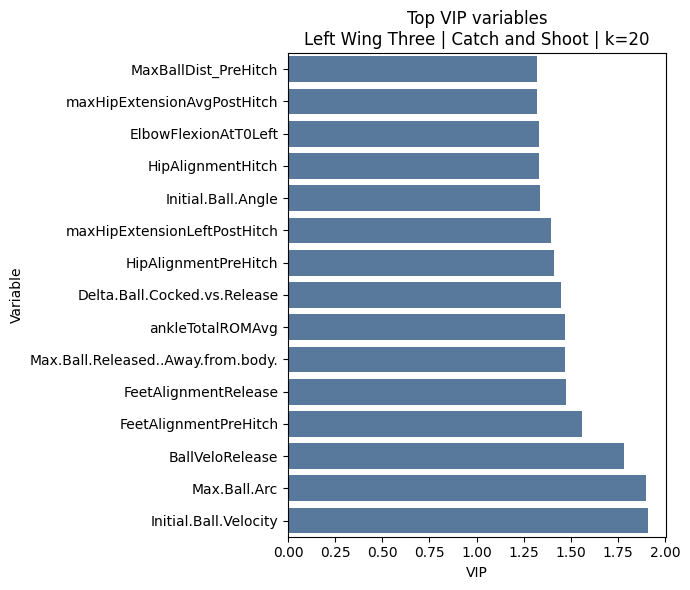

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Initial.Ball.Velocity,0.244458,0.244458
1,Delta.Ball.Cocked.vs.Release,0.225272,-0.225272
2,Max.Ball.Released..Away.from.body.,0.198297,-0.198297
3,Max.Ball.Arc,0.186750,0.186750
4,MaxBallDist_PreHitch,0.175752,-0.175752
5,FeetAlignmentRelease,0.157697,0.157697
6,maxAnklePlantarflexionLeftPostHitch,0.153144,-0.153144
7,PreHitchYDelta,0.153091,-0.153091
8,maxAnklePlantarflexionLeftPreHitch,0.145731,-0.145731
9,maxAnkleDorsiflexionLeftPreHitch,0.143557,-0.143557


- **PLS2**

,feature,abs_weight,PLS2
0,Initial.Ball.Velocity,0.183809,0.183809
1,Delta.Ball.Cocked.vs.Release,0.146946,-0.146946
2,maxAnklePlantarflexionRightPreHitch,0.138049,0.138049
3,maxAnkleDorsiflexionRightPreHitch,0.133536,0.133536
4,Max.Ball.Arc,0.126638,0.126638
5,maxElbowExtensionAvgPostHitch,0.123766,-0.123766
6,maxKneeExtensionAvgPreHitch,0.122677,-0.122677
7,maxElbowFlexionAvgPostHitch,0.122414,-0.122414
8,BallVeloRelease,0.114931,0.114931
9,TorsoVeloPreHitch,0.113923,-0.113923


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS5,0.396277,0.396277,3.618426
1,PLS1,0.375295,0.375295,27.559817
2,PLS3,0.360622,0.360622,16.238373
3,PLS4,0.338896,0.338896,3.154525
4,PLS6,-0.309357,0.309357,3.545797
5,PLS8,-0.248912,0.248912,3.915576
6,PLS2,-0.245923,0.245923,41.542928
7,PLS9,0.201005,0.201005,3.653294
8,PLS10,0.148338,0.148338,3.974726
9,PLS7,-0.130017,0.130017,18.545912


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_wing_two__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__left_wing_two__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
timeAtStartofMovement,2.068310
timeAtEndofHitch,2.025265
timeAtStartofHitch,2.018841
timeAtRelease,1.985996
maxShoulderExtensionLeftPreHitch,1.927925
ShoulderFlexionAtT0Left,1.921614
maxShoulderExtensionAvgPreHitch,1.895672
BallVeloPreHitch,1.624512
MaxStanceGapPreHitch,1.621622
ShoulderAlignmentRelease,1.614280


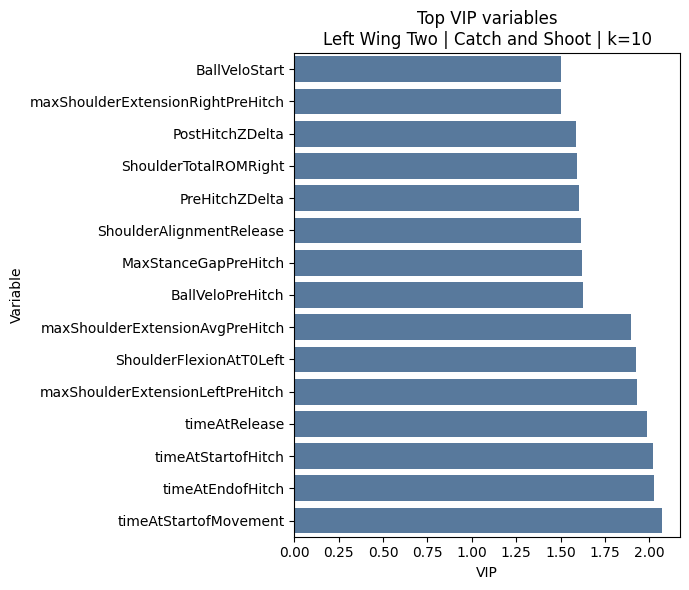

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,PreHitchZDelta,0.201003,0.201003
1,maxShoulderExtensionAvgPreHitch,0.164806,-0.164806
2,maxElbowExtensionAvgHitch,0.163271,0.163271
3,maxElbowFlexionAvgPostHitch,0.154438,0.154438
4,maxShoulderExtensionRightPreHitch,0.152400,-0.152400
5,ShoulderTotalROMRight,0.151270,0.151270
6,HitchYDelta,0.150026,0.150026
7,PostHitchZDelta,0.149045,0.149045
8,BallVeloStart,0.145571,-0.145571
9,ShoulderFlexionAtT0Right,0.142625,-0.142625


- **PLS2**

,feature,abs_weight,PLS2
0,maxShoulderExtensionRightPreHitch,0.159884,0.159884
1,ShoulderFlexionAtT0Right,0.159609,0.159609
2,ShoulderTotalROMRight,0.142743,-0.142743
3,timeToMaxTorsoFlexionPostHitch,0.115541,0.115541
4,timeToMaxTorsoExtensionPostHitch,0.115541,0.115541
5,ShoulderAlignmentPostHitch,0.113753,-0.113753
6,PercTimePostHitch,0.112962,0.112962
7,maxShoulderExtensionRightHitch,0.111875,0.111875
8,timeToMaxTorsoFlexionPreHitch,0.111408,0.111408
9,timeToMaxTorsoExtensionPreHitch,0.111408,0.111408


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS5,0.396277,0.396277,3.618426
1,PLS1,0.375295,0.375295,27.559817
2,PLS3,0.360622,0.360622,16.238373
3,PLS4,0.338896,0.338896,3.154525
4,PLS6,-0.309357,0.309357,3.545797
5,PLS8,-0.248912,0.248912,3.915576
6,PLS2,-0.245923,0.245923,41.542928
7,PLS9,0.201005,0.201005,3.653294
8,PLS11,0.180093,0.180093,2.462771
9,PLS12,0.170038,0.170038,1.723447


**Component definitions (exact weights) saved:** `outputs\pls_definition__left_wing_two__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__left_wing_two__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
timeAtStartofMovement,1.928949
timeAtEndofHitch,1.889731
timeAtStartofHitch,1.882902
timeAtRelease,1.852473
ShoulderFlexionAtT0Left,1.806829
maxShoulderExtensionLeftPreHitch,1.803284
maxShoulderExtensionAvgPreHitch,1.771270
ShoulderAlignmentRelease,1.692592
MaxStanceGapPreHitch,1.629370
FeetAlignmentPreHitch,1.606156


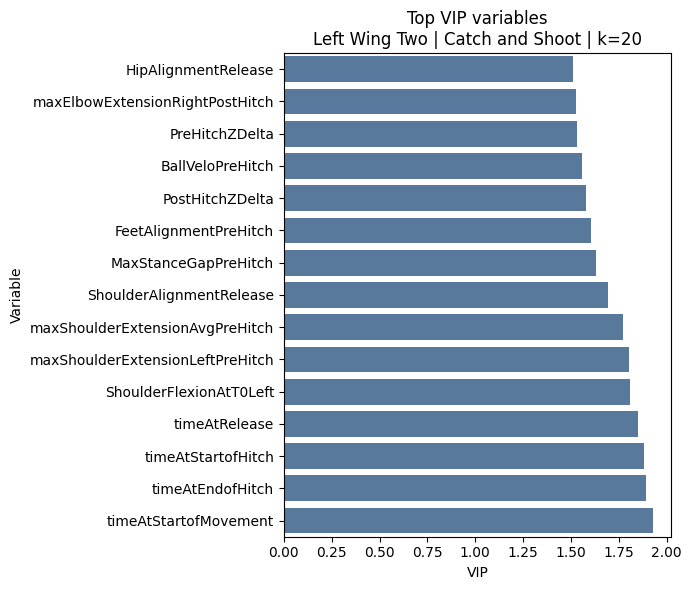

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,PreHitchZDelta,0.201003,0.201003
1,maxShoulderExtensionAvgPreHitch,0.164806,-0.164806
2,maxElbowExtensionAvgHitch,0.163271,0.163271
3,maxElbowFlexionAvgPostHitch,0.154438,0.154438
4,maxShoulderExtensionRightPreHitch,0.152400,-0.152400
5,ShoulderTotalROMRight,0.151270,0.151270
6,HitchYDelta,0.150026,0.150026
7,PostHitchZDelta,0.149045,0.149045
8,BallVeloStart,0.145571,-0.145571
9,ShoulderFlexionAtT0Right,0.142625,-0.142625


- **PLS2**

,feature,abs_weight,PLS2
0,maxShoulderExtensionRightPreHitch,0.159884,0.159884
1,ShoulderFlexionAtT0Right,0.159609,0.159609
2,ShoulderTotalROMRight,0.142743,-0.142743
3,timeToMaxTorsoFlexionPostHitch,0.115541,0.115541
4,timeToMaxTorsoExtensionPostHitch,0.115541,0.115541
5,ShoulderAlignmentPostHitch,0.113753,-0.113753
6,PercTimePostHitch,0.112962,0.112962
7,maxShoulderExtensionRightHitch,0.111875,0.111875
8,timeToMaxTorsoFlexionPreHitch,0.111408,0.111408
9,timeToMaxTorsoExtensionPreHitch,0.111408,0.111408


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.264330,0.264330,18.896801
1,PLS4,-0.206565,0.206565,5.962628
2,PLS3,-0.197927,0.197927,8.033664
3,PLS2,0.193399,0.193399,36.693515
4,PLS8,-0.122692,0.122692,3.700136
5,PLS10,0.120900,0.120900,3.357204
6,PLS7,-0.117867,0.117867,6.758234
7,PLS6,-0.114354,0.114354,6.973287
8,PLS5,-0.107587,0.107587,15.141970
9,PLS9,-0.101382,0.101382,5.703768


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_three__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__middle_three__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
BallYHitch,1.919827
BallYPreHitch,1.915496
BallYPostHitch,1.872571
BallYRelease,1.797219
Max.Ball.Arc,1.674992
Shot.Distance,1.671277
Shot.Y.Pos,1.657032
timeAtStartofMovement,1.588034
timeAtStartofHitch,1.486555
timeAtEndofHitch,1.470669


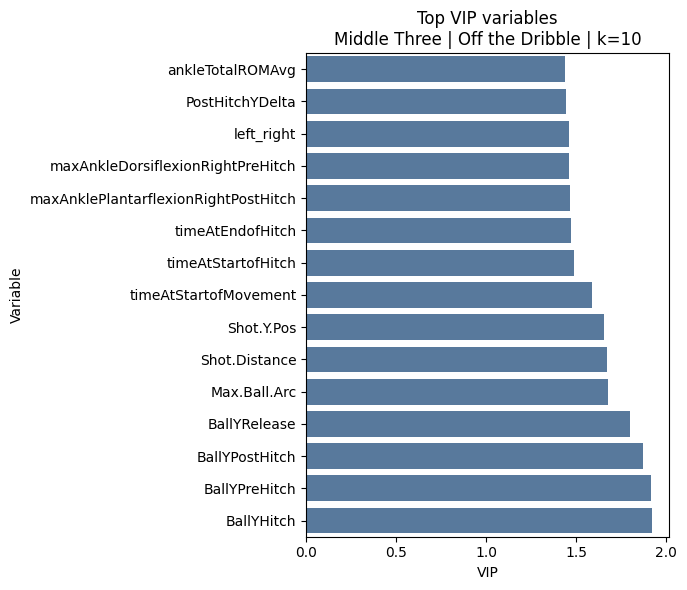

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallYPreHitch,0.208797,0.208797
1,BallYHitch,0.206700,0.206700
2,BallYPostHitch,0.202254,0.202254
3,BallYRelease,0.193942,0.193942
4,Max.Ball.Arc,0.170222,0.170222
5,Shot.Distance,0.169293,0.169293
6,Shot.Y.Pos,0.160601,0.160601
7,FeetAlignmentPreHitch,0.136653,-0.136653
8,timeAtStartofMovement,0.136498,-0.136498
9,BallZRelease,0.124204,0.124204


- **PLS2**

,feature,abs_weight,PLS2
0,timeToMaxKneeFlexionRightPreHitch,0.123143,0.123143
1,timeToMaxElbowFlexionRightPreHitch,0.114408,0.114408
2,timeToMaxElbowExtensionRightPreHitch,0.114155,0.114155
3,timeAtStartofHitch,0.113526,0.113526
4,timeAtEndofHitch,0.112984,0.112984
5,timeToMaxAnklePlantarflexionRightHitch,0.112554,0.112554
6,timeToMaxKneeFlexionLeftHitch,0.111638,0.111638
7,timeToMaxTorsoExtensionHitch,0.110579,0.110579
8,timeAtRelease,0.109872,0.109872
9,timeToMaxKneeExtensionLeftHitch,0.109746,0.109746


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.264330,0.264330,18.896801
1,PLS4,-0.206565,0.206565,5.962628
2,PLS3,-0.197927,0.197927,8.033664
3,PLS2,0.193399,0.193399,36.693515
4,PLS12,-0.127828,0.127828,2.618938
5,PLS8,-0.122692,0.122692,3.700136
6,PLS10,0.120900,0.120900,3.357204
7,PLS7,-0.117867,0.117867,6.758234
8,PLS6,-0.114354,0.114354,6.973287
9,PLS11,-0.113978,0.113978,3.484716


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_three__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__middle_three__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
FeetAlignmentHitch,1.777554
left_right,1.751709
BallYHitch,1.723586
BallYPreHitch,1.722778
BallYPostHitch,1.679965
BallYRelease,1.626830
Shot.Y.Pos,1.565295
Shot.Distance,1.557094
timeAtStartofMovement,1.532176
Max.Ball.Arc,1.525846


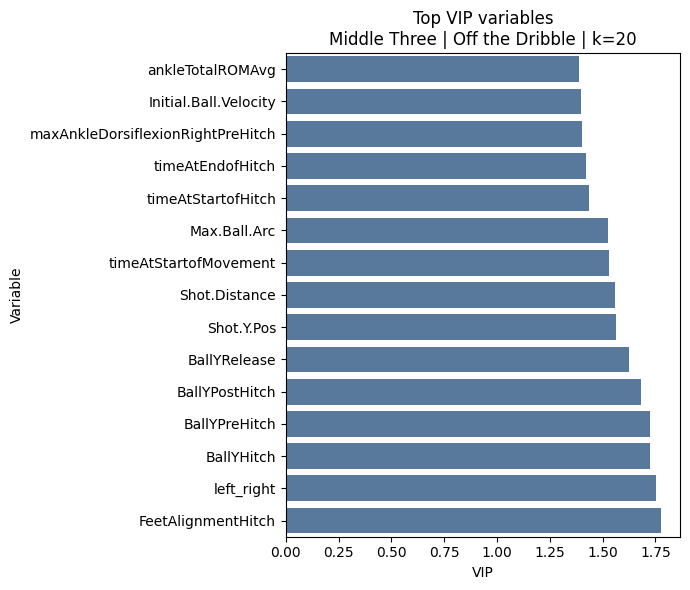

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallYPreHitch,0.208797,0.208797
1,BallYHitch,0.206700,0.206700
2,BallYPostHitch,0.202254,0.202254
3,BallYRelease,0.193942,0.193942
4,Max.Ball.Arc,0.170222,0.170222
5,Shot.Distance,0.169293,0.169293
6,Shot.Y.Pos,0.160601,0.160601
7,FeetAlignmentPreHitch,0.136653,-0.136653
8,timeAtStartofMovement,0.136498,-0.136498
9,BallZRelease,0.124204,0.124204


- **PLS2**

,feature,abs_weight,PLS2
0,timeToMaxKneeFlexionRightPreHitch,0.123143,0.123143
1,timeToMaxElbowFlexionRightPreHitch,0.114408,0.114408
2,timeToMaxElbowExtensionRightPreHitch,0.114155,0.114155
3,timeAtStartofHitch,0.113526,0.113526
4,timeAtEndofHitch,0.112984,0.112984
5,timeToMaxAnklePlantarflexionRightHitch,0.112554,0.112554
6,timeToMaxKneeFlexionLeftHitch,0.111638,0.111638
7,timeToMaxTorsoExtensionHitch,0.110579,0.110579
8,timeAtRelease,0.109872,0.109872
9,timeToMaxKneeExtensionLeftHitch,0.109746,0.109746


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS2,-0.148151,0.148151,21.186539
1,PLS1,-0.123941,0.123941,29.423275
2,PLS3,0.095406,0.095406,14.549814
3,PLS4,0.086398,0.086398,4.871090
4,PLS5,0.067327,0.067327,9.236847
5,PLS10,-0.066328,0.066328,1.900400
6,PLS6,0.058131,0.058131,4.305174
7,PLS8,-0.052352,0.052352,3.170859
8,PLS7,-0.045951,0.045951,8.298893
9,PLS9,-0.045609,0.045609,2.842929


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_three__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__middle_three__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,3.012895
BallYRelease,2.068913
BallYHitch,2.049520
BallYPostHitch,1.992843
Shot.Y.Pos,1.954451
Shot.Distance,1.935890
Initial.Ball.Velocity,1.903996
BallYPreHitch,1.902761
Max.Ball.Arc,1.571914
MaxStanceGapRelease,1.530820


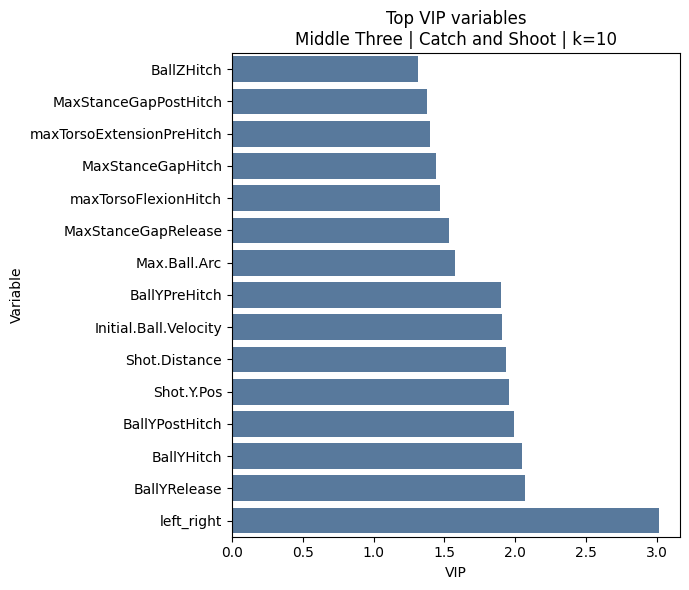

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Shot.Distance,0.214374,0.214374
1,BallYRelease,0.212723,0.212723
2,BallYHitch,0.211172,0.211172
3,Shot.Y.Pos,0.210597,0.210597
4,BallYPostHitch,0.203264,0.203264
5,BallYPreHitch,0.189448,0.189448
6,Initial.Ball.Velocity,0.170730,0.170730
7,maxTorsoFlexionHitch,0.159188,0.159188
8,maxTorsoExtensionPreHitch,0.144671,0.144671
9,BallZHitch,0.138188,0.138188


- **PLS2**

,feature,abs_weight,PLS2
0,BallYRelease,0.136518,0.136518
1,BallYHitch,0.132484,0.132484
2,BallYPostHitch,0.128453,0.128453
3,left_right,0.126473,-0.126473
4,BallYPreHitch,0.122735,0.122735
5,Shot.Distance,0.109862,0.109862
6,timeToMaxHipExtensionRightPostHitch,0.109615,0.109615
7,timeToMaxHipFlexionRightPostHitch,0.109445,0.109445
8,Shot.Y.Pos,0.107535,0.107535
9,timeToMaxShoulderExtensionRightHitch,0.106585,0.106585


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS2,-0.148151,0.148151,21.186539
1,PLS1,-0.123941,0.123941,29.423275
2,PLS3,0.095406,0.095406,14.549814
3,PLS4,0.086398,0.086398,4.871090
4,PLS5,0.067327,0.067327,9.236847
5,PLS10,-0.066328,0.066328,1.900400
6,PLS6,0.058131,0.058131,4.305174
7,PLS8,-0.052352,0.052352,3.170859
8,PLS12,-0.051481,0.051481,3.196907
9,PLS11,0.046807,0.046807,4.221108


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_three__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__middle_three__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.899374
BallYRelease,1.889370
BallYHitch,1.870347
Initial.Ball.Velocity,1.858979
BallYPostHitch,1.820951
Shot.Y.Pos,1.797250
Shot.Distance,1.760958
BallYPreHitch,1.744774
Max.Ball.Arc,1.560686
MaxStanceGapRelease,1.480805


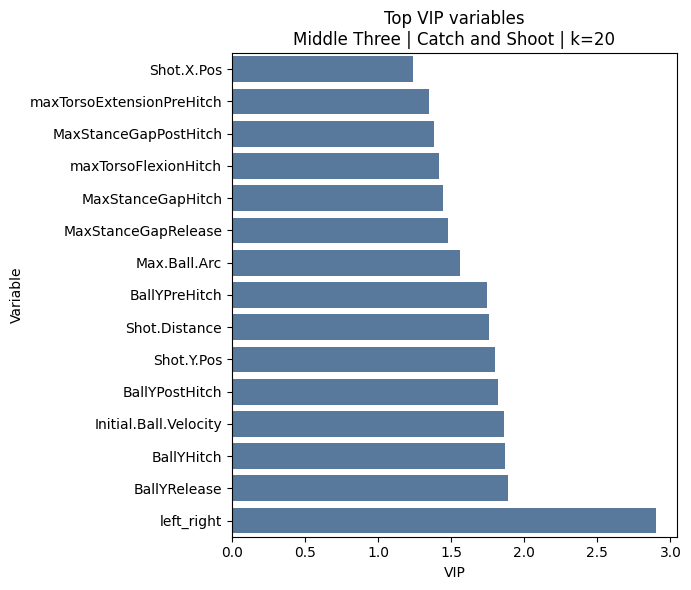

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Shot.Distance,0.214374,0.214374
1,BallYRelease,0.212723,0.212723
2,BallYHitch,0.211172,0.211172
3,Shot.Y.Pos,0.210597,0.210597
4,BallYPostHitch,0.203264,0.203264
5,BallYPreHitch,0.189448,0.189448
6,Initial.Ball.Velocity,0.170730,0.170730
7,maxTorsoFlexionHitch,0.159188,0.159188
8,maxTorsoExtensionPreHitch,0.144671,0.144671
9,BallZHitch,0.138188,0.138188


- **PLS2**

,feature,abs_weight,PLS2
0,BallYRelease,0.136518,0.136518
1,BallYHitch,0.132484,0.132484
2,BallYPostHitch,0.128453,0.128453
3,left_right,0.126473,-0.126473
4,BallYPreHitch,0.122735,0.122735
5,Shot.Distance,0.109862,0.109862
6,timeToMaxHipExtensionRightPostHitch,0.109615,0.109615
7,timeToMaxHipFlexionRightPostHitch,0.109445,0.109445
8,Shot.Y.Pos,0.107535,0.107535
9,timeToMaxShoulderExtensionRightHitch,0.106585,0.106585


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.347012,0.347012,8.466731
1,PLS2,0.343286,0.343286,16.780372
2,PLS7,-0.314610,0.314610,2.432717
3,PLS5,0.314455,0.314455,11.403705
4,PLS1,-0.303382,0.303382,43.833513
5,PLS8,0.263627,0.263627,3.923821
6,PLS10,0.261018,0.261018,1.095693
7,PLS9,-0.245024,0.245024,1.642104
8,PLS6,0.218437,0.218437,6.688774
9,PLS4,0.186335,0.186335,36.871044


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_two__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__middle_two__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
maxKneeExtensionRightPostHitch,2.110925
MaxStanceGapPostHitch,1.736483
maxAnklePlantarflexionLeftPostHitch,1.698555
TorsoVeloPostHitch,1.682425
maxKneeExtensionAvgPostHitch,1.584506
HitchXDelta,1.559947
maxKneeExtensionLeftPostHitch,1.519736
maxAnklePlantarflexionAvgPostHitch,1.512496
MaxBallDist_Hitch,1.505952
TorsoVeloPreHitch,1.494649


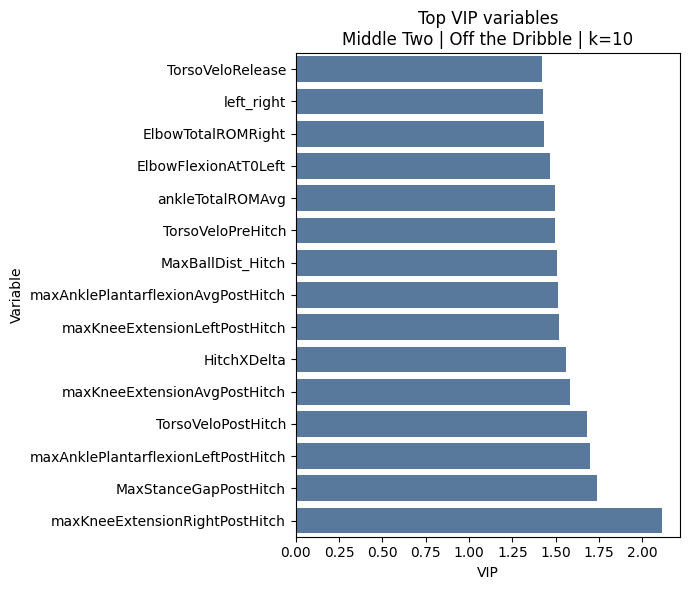

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,TorsoVeloRelease,0.147141,0.147141
1,maxHipFlexionRightPostHitch,0.122026,0.122026
2,timeToMaxElbowFlexionRightHitch,0.116494,-0.116494
3,maxHipExtensionRightHitch,0.113689,0.113689
4,timeToMaxHipFlexionRightPostHitch,0.112761,-0.112761
5,timeToMaxKneeExtensionLeftHitch,0.110336,-0.110336
6,maxHipFlexionAvgPostHitch,0.105219,0.105219
7,timeToMaxElbowExtensionRightPostHitch,0.102988,-0.102988
8,timeToMaxKneeFlexionRightPostHitch,0.102957,-0.102957
9,timeToMaxAnkleDorsiflexionLeftPostHitch,0.102915,-0.102915


- **PLS2**

,feature,abs_weight,PLS2
0,maxElbowExtensionRightPostHitch,0.162235,0.162235
1,TorsoFlexionAtT0,0.154709,0.154709
2,maxElbowExtensionAvgPostHitch,0.148768,0.148768
3,maxKneeExtensionRightPostHitch,0.147647,-0.147647
4,TorsoVeloRelease,0.138235,-0.138235
5,MaxBallDist_PostHitch,0.135412,-0.135412
6,maxShoulderExtensionAvgPreHitch,0.127986,-0.127986
7,TorsoVeloPreHitch,0.127589,0.127589
8,maxElbowExtensionLeftPostHitch,0.127221,0.127221
9,maxAnklePlantarflexionRightPostHitch,0.122080,0.122080


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS3,0.347012,0.347012,8.466731
1,PLS2,0.343286,0.343286,16.780372
2,PLS7,-0.314610,0.314610,2.432717
3,PLS5,0.314455,0.314455,11.403705
4,PLS1,-0.303382,0.303382,43.833513
5,PLS8,0.263627,0.263627,3.923821
6,PLS10,0.261018,0.261018,1.095693
7,PLS9,-0.245024,0.245024,1.642104
8,PLS6,0.218437,0.218437,6.688774
9,PLS12,-0.197742,0.197742,1.064652


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_two__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__middle_two__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
maxKneeExtensionRightPostHitch,1.989469
MaxStanceGapPostHitch,1.702349
TorsoVeloPostHitch,1.697336
left_right,1.683187
maxAnklePlantarflexionLeftPostHitch,1.576986
HitchXDelta,1.570972
ElbowFlexionAtT0Left,1.554963
maxKneeExtensionAvgPostHitch,1.516317
maxKneeExtensionLeftPostHitch,1.510488
TorsoVeloPreHitch,1.479875


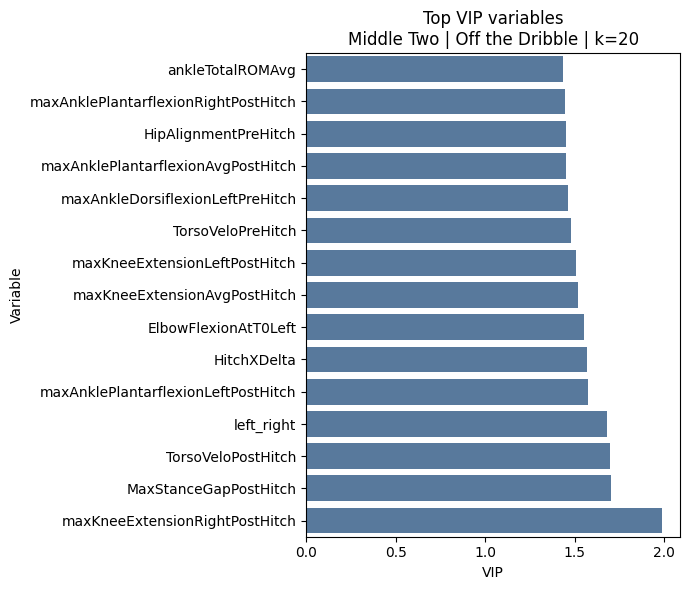

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,TorsoVeloRelease,0.147141,0.147141
1,maxHipFlexionRightPostHitch,0.122026,0.122026
2,timeToMaxElbowFlexionRightHitch,0.116494,-0.116494
3,maxHipExtensionRightHitch,0.113689,0.113689
4,timeToMaxHipFlexionRightPostHitch,0.112761,-0.112761
5,timeToMaxKneeExtensionLeftHitch,0.110336,-0.110336
6,maxHipFlexionAvgPostHitch,0.105219,0.105219
7,timeToMaxElbowExtensionRightPostHitch,0.102988,-0.102988
8,timeToMaxKneeFlexionRightPostHitch,0.102957,-0.102957
9,timeToMaxAnkleDorsiflexionLeftPostHitch,0.102915,-0.102915


- **PLS2**

,feature,abs_weight,PLS2
0,maxElbowExtensionRightPostHitch,0.162235,0.162235
1,TorsoFlexionAtT0,0.154709,0.154709
2,maxElbowExtensionAvgPostHitch,0.148768,0.148768
3,maxKneeExtensionRightPostHitch,0.147647,-0.147647
4,TorsoVeloRelease,0.138235,-0.138235
5,MaxBallDist_PostHitch,0.135412,-0.135412
6,maxShoulderExtensionAvgPreHitch,0.127986,-0.127986
7,TorsoVeloPreHitch,0.127589,0.127589
8,maxElbowExtensionLeftPostHitch,0.127221,0.127221
9,maxAnklePlantarflexionRightPostHitch,0.122080,0.122080


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.249151,0.249151,56.233451
1,PLS2,-0.212927,0.212927,17.403212
2,PLS6,-0.201436,0.201436,3.932826
3,PLS7,-0.185786,0.185786,3.902755
4,PLS3,0.180472,0.180472,15.187605
5,PLS9,-0.150663,0.150663,1.612126
6,PLS10,0.144046,0.144046,2.990291
7,PLS5,0.142483,0.142483,5.095795
8,PLS4,0.106588,0.106588,17.863644
9,PLS8,-0.095211,0.095211,7.879668


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_two__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__middle_two__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
Pass.Direction,1.805999
MaxStanceGapPostHitch,1.787226
Delta.Ball.Cocked.vs.Release,1.592837
Max.Ball.Released..Away.from.body.,1.591712
TorsoVeloPostHitch,1.546307
BallVeloStart,1.498996
maxShoulderExtensionRightHitch,1.483494
MaxStanceGapHitch,1.474920
ShoulderAlignmentHitch,1.449972
maxShoulderExtensionAvgHitch,1.428813


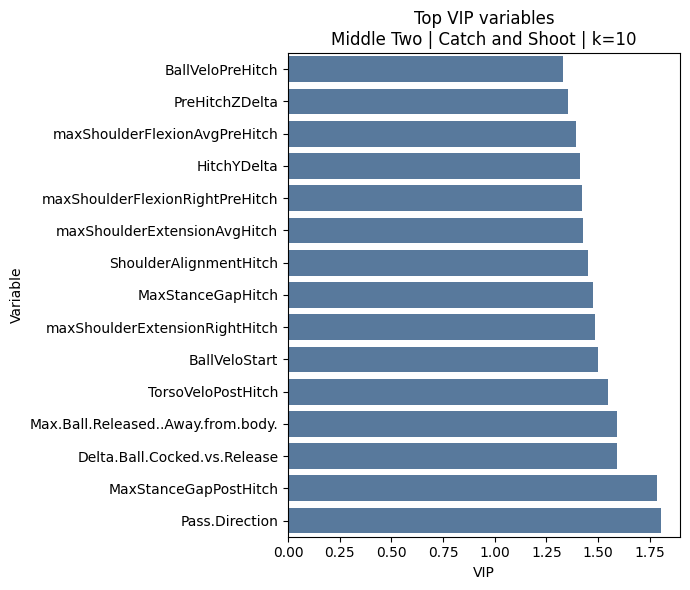

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,TorsoVeloPostHitch,0.128055,0.128055
1,ShoulderFlexionAtT0Left,0.117151,-0.117151
2,TorsoVeloRelease,0.115992,-0.115992
3,maxElbowFlexionLeftHitch,0.113560,0.113560
4,ShoulderTotalROMLeft,0.113553,0.113553
5,maxShoulderExtensionLeftPreHitch,0.111161,-0.111161
6,Starting.Ball.Height,0.110478,-0.110478
7,BallZPreHitch,0.110468,-0.110468
8,timeToMaxHipFlexionLeftPreHitch,0.106309,0.106309
9,timeToMaxElbowFlexionRightPreHitch,0.104474,0.104474


- **PLS2**

,feature,abs_weight,PLS2
0,Max.Ball.Released..Away.from.body.,0.164907,0.164907
1,Delta.Ball.Cocked.vs.Release,0.162555,0.162555
2,Pass.Direction,0.151156,-0.151156
3,Hitch.Time,0.130944,0.130944
4,BallXPreHitch,0.125009,0.125009
5,TorsoVeloRelease,0.122119,0.122119
6,BallXRelease,0.121806,0.121806
7,BallXPostHitch,0.118578,0.118578
8,timeToMaxHipExtensionRightPostHitch,0.118471,0.118471
9,PreHitchZDelta,0.117578,-0.117578


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.249151,0.249151,56.233451
1,PLS2,-0.212927,0.212927,17.403212
2,PLS6,-0.201436,0.201436,3.932826
3,PLS7,-0.185786,0.185786,3.902755
4,PLS3,0.180472,0.180472,15.187605
5,PLS13,0.170769,0.170769,1.133787
6,PLS9,-0.150663,0.150663,1.612126
7,PLS10,0.144046,0.144046,2.990291
8,PLS5,0.142483,0.142483,5.095795
9,PLS17,0.137228,0.137228,1.526557


**Component definitions (exact weights) saved:** `outputs\pls_definition__middle_two__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__middle_two__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
Pass.Direction,1.827513
MaxStanceGapPreHitch,1.702997
ShoulderAlignmentHitch,1.680212
MaxStanceGapPostHitch,1.634605
FeetAlignmentHitch,1.499893
BallVeloStart,1.480270
Delta.Ball.Cocked.vs.Release,1.448845
Max.Ball.Arc,1.419222
MaxStanceGapHitch,1.394444
PreHitchZDelta,1.380393


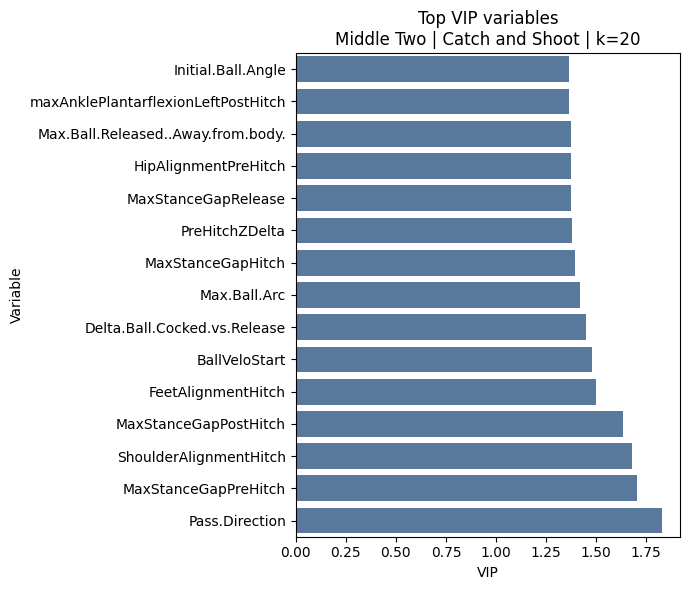

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,TorsoVeloPostHitch,0.128055,0.128055
1,ShoulderFlexionAtT0Left,0.117151,-0.117151
2,TorsoVeloRelease,0.115992,-0.115992
3,maxElbowFlexionLeftHitch,0.113560,0.113560
4,ShoulderTotalROMLeft,0.113553,0.113553
5,maxShoulderExtensionLeftPreHitch,0.111161,-0.111161
6,Starting.Ball.Height,0.110478,-0.110478
7,BallZPreHitch,0.110468,-0.110468
8,timeToMaxHipFlexionLeftPreHitch,0.106309,0.106309
9,timeToMaxElbowFlexionRightPreHitch,0.104474,0.104474


- **PLS2**

,feature,abs_weight,PLS2
0,Max.Ball.Released..Away.from.body.,0.164907,0.164907
1,Delta.Ball.Cocked.vs.Release,0.162555,0.162555
2,Pass.Direction,0.151156,-0.151156
3,Hitch.Time,0.130944,0.130944
4,BallXPreHitch,0.125009,0.125009
5,TorsoVeloRelease,0.122119,0.122119
6,BallXRelease,0.121806,0.121806
7,BallXPostHitch,0.118578,0.118578
8,timeToMaxHipExtensionRightPostHitch,0.118471,0.118471
9,PreHitchZDelta,0.117578,-0.117578


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.158248,0.158248,13.555055
1,PLS3,-0.119750,0.119750,14.830381
2,PLS4,-0.099833,0.099833,9.737816
3,PLS8,0.096063,0.096063,2.557585
4,PLS6,-0.093096,0.093096,4.379813
5,PLS7,-0.086362,0.086362,4.267998
6,PLS10,-0.084705,0.084705,3.622734
7,PLS5,-0.084168,0.084168,5.306912
8,PLS2,-0.079836,0.079836,24.719816
9,PLS9,-0.072395,0.072395,4.476327


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_three__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_three__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
Max.Ball.Arc,1.812727
BallVeloRelease,1.728739
timeAtEndofHitch,1.541784
timeAtStartofHitch,1.539997
HitchYDelta,1.531129
maxHipExtensionLeftPostHitch,1.521385
maxTorsoExtensionHitch,1.512215
timeAtRelease,1.503281
timeAtStartofMovement,1.493123
TorsoTotalROMAvg,1.420503


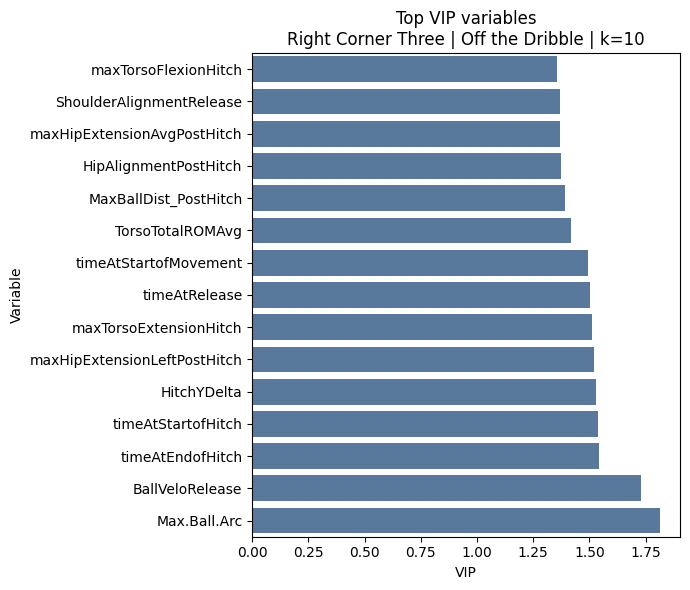

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Max.Ball.Arc,0.182904,0.182904
1,maxHipExtensionLeftPostHitch,0.182623,-0.182623
2,maxHipExtensionAvgPostHitch,0.164140,-0.164140
3,maxTorsoExtensionHitch,0.161264,-0.161264
4,Post.Hitch.Time,0.145204,0.145204
5,Delta.Ball.Cocked.vs.Release,0.139455,0.139455
6,timeAtStartofHitch,0.131520,-0.131520
7,timeAtEndofHitch,0.130202,-0.130202
8,TorsoVeloPostHitch,0.127515,-0.127515
9,Max.Ball.Cocked,0.127337,-0.127337


- **PLS2**

,feature,abs_weight,PLS2
0,Max.Ball.Arc,0.145891,0.145891
1,HitchYDelta,0.138023,0.138023
2,TorsoTotalROMAvg,0.136437,-0.136437
3,TorsoVeloHitch,0.125966,0.125966
4,maxAnklePlantarflexionLeftHitch,0.121731,-0.121731
5,maxAnkleDorsiflexionAvgHitch,0.121360,-0.121360
6,timeToMaxAnkleDorsiflexionRightPreHitch,0.115883,-0.115883
7,timeAtRelease,0.111576,-0.111576
8,MaxStanceGapRelease,0.108997,0.108997
9,timeAtStartofHitch,0.108577,-0.108577


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.158248,0.158248,13.555055
1,PLS3,-0.119750,0.119750,14.830381
2,PLS4,-0.099833,0.099833,9.737816
3,PLS8,0.096063,0.096063,2.557585
4,PLS6,-0.093096,0.093096,4.379813
5,PLS7,-0.086362,0.086362,4.267998
6,PLS10,-0.084705,0.084705,3.622734
7,PLS5,-0.084168,0.084168,5.306912
8,PLS2,-0.079836,0.079836,24.719816
9,PLS9,-0.072395,0.072395,4.476327


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_three__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_three__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
Max.Ball.Arc,1.653525
BallVeloRelease,1.600339
timeAtStartofHitch,1.495997
timeAtEndofHitch,1.491210
timeAtRelease,1.457177
timeAtStartofMovement,1.438023
HitchYDelta,1.416130
maxHipExtensionLeftPostHitch,1.414954
maxTorsoExtensionHitch,1.398445
MaxBallDist_PostHitch,1.376201


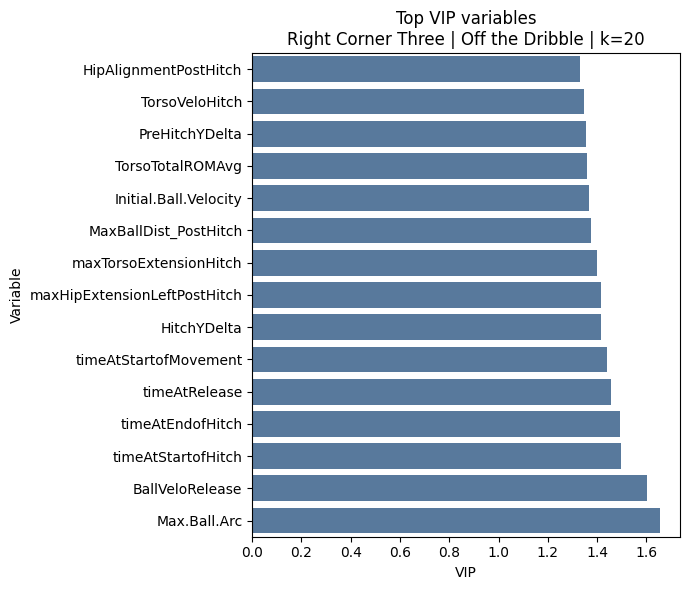

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,Max.Ball.Arc,0.182904,0.182904
1,maxHipExtensionLeftPostHitch,0.182623,-0.182623
2,maxHipExtensionAvgPostHitch,0.164140,-0.164140
3,maxTorsoExtensionHitch,0.161264,-0.161264
4,Post.Hitch.Time,0.145204,0.145204
5,Delta.Ball.Cocked.vs.Release,0.139455,0.139455
6,timeAtStartofHitch,0.131520,-0.131520
7,timeAtEndofHitch,0.130202,-0.130202
8,TorsoVeloPostHitch,0.127515,-0.127515
9,Max.Ball.Cocked,0.127337,-0.127337


- **PLS2**

,feature,abs_weight,PLS2
0,Max.Ball.Arc,0.145891,0.145891
1,HitchYDelta,0.138023,0.138023
2,TorsoTotalROMAvg,0.136437,-0.136437
3,TorsoVeloHitch,0.125966,0.125966
4,maxAnklePlantarflexionLeftHitch,0.121731,-0.121731
5,maxAnkleDorsiflexionAvgHitch,0.121360,-0.121360
6,timeToMaxAnkleDorsiflexionRightPreHitch,0.115883,-0.115883
7,timeAtRelease,0.111576,-0.111576
8,MaxStanceGapRelease,0.108997,0.108997
9,timeAtStartofHitch,0.108577,-0.108577


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.135160,0.135160,16.914818
1,PLS3,0.120932,0.120932,15.840529
2,PLS5,0.109235,0.109235,4.556523
3,PLS4,0.089656,0.089656,6.059336
4,PLS2,0.088469,0.088469,25.607364
5,PLS6,-0.077566,0.077566,7.104879
6,PLS7,-0.074594,0.074594,5.087468
7,PLS9,-0.074565,0.074565,3.125100
8,PLS10,-0.061566,0.061566,2.657687
9,PLS8,-0.052922,0.052922,8.752900


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_three__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_three__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,3.293265
MaxStanceGapRelease,1.739900
MaxStanceGapPreHitch,1.679591
Shot.Distance,1.648800
MaxStanceGapHitch,1.647047
MaxStanceGapPostHitch,1.631979
PreHitchXDelta,1.610564
Shot.X.Pos,1.579374
BallVeloPreHitch,1.491860
ShoulderTotalROMRight,1.477470


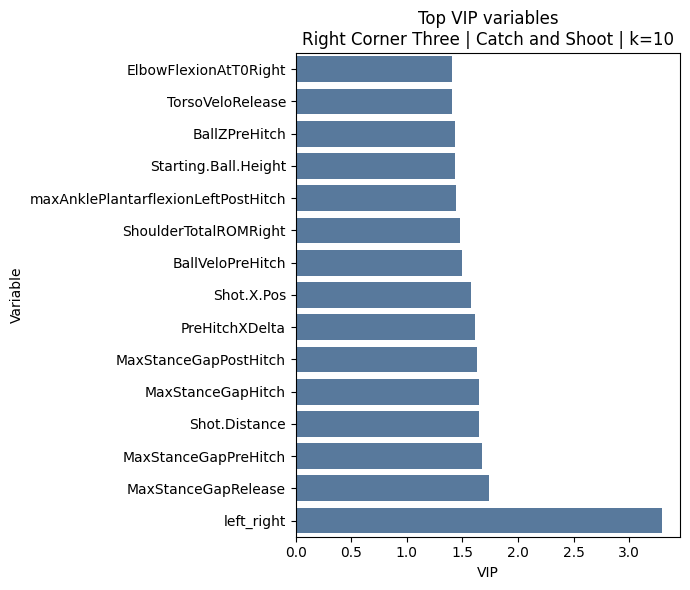

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,left_right,0.212795,0.212795
1,BallVeloPreHitch,0.180273,0.180273
2,MaxStanceGapRelease,0.158738,-0.158738
3,Starting.Ball.Height,0.151561,-0.151561
4,BallZPreHitch,0.151560,-0.151560
5,MaxStanceGapPreHitch,0.147215,-0.147215
6,BallZHitch,0.145959,-0.145959
7,maxShoulderExtensionRightPreHitch,0.141469,-0.141469
8,maxShoulderExtensionAvgPreHitch,0.139357,-0.139357
9,MaxStanceGapHitch,0.137131,-0.137131


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.224321,0.224321
1,Shot.Distance,0.158061,-0.158061
2,Shot.X.Pos,0.152018,-0.152018
3,TorsoVeloHitch,0.135763,-0.135763
4,MaxStanceGapHitch,0.130895,-0.130895
5,maxHipExtensionRightHitch,0.129889,0.129889
6,maxAnklePlantarflexionRightPostHitch,0.128990,-0.128990
7,maxHipExtensionAvgHitch,0.127634,0.127634
8,maxHipFlexionAvgPostHitch,0.126620,0.126620
9,MaxStanceGapPostHitch,0.124340,-0.124340


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.135160,0.135160,16.914818
1,PLS3,0.120932,0.120932,15.840529
2,PLS5,0.109235,0.109235,4.556523
3,PLS4,0.089656,0.089656,6.059336
4,PLS2,0.088469,0.088469,25.607364
5,PLS6,-0.077566,0.077566,7.104879
6,PLS7,-0.074594,0.074594,5.087468
7,PLS9,-0.074565,0.074565,3.125100
8,PLS11,0.070118,0.070118,1.787518
9,PLS15,-0.063872,0.063872,1.850736


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_three__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_three__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,3.123251
MaxStanceGapRelease,1.596494
PreHitchXDelta,1.548376
Shot.Distance,1.537598
MaxStanceGapPostHitch,1.535551
MaxStanceGapHitch,1.533934
MaxStanceGapPreHitch,1.516611
Shot.X.Pos,1.479669
maxAnklePlantarflexionLeftPostHitch,1.456023
TorsoVeloRelease,1.433021


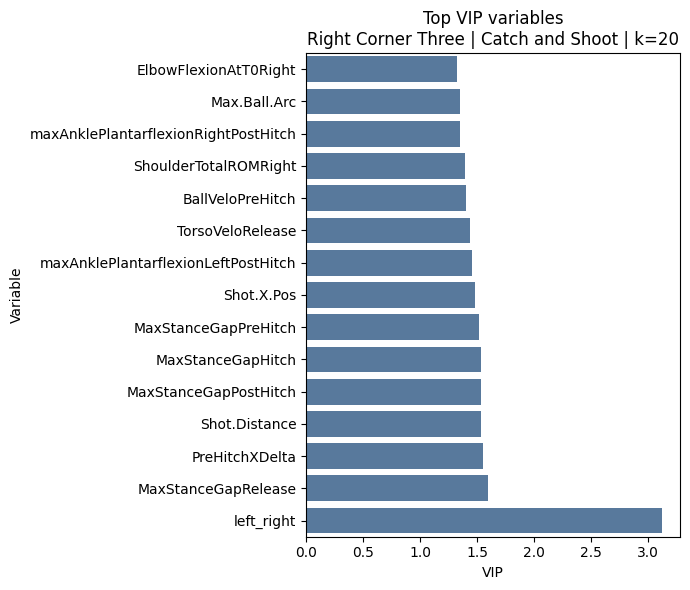

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,left_right,0.212795,0.212795
1,BallVeloPreHitch,0.180273,0.180273
2,MaxStanceGapRelease,0.158738,-0.158738
3,Starting.Ball.Height,0.151561,-0.151561
4,BallZPreHitch,0.151560,-0.151560
5,MaxStanceGapPreHitch,0.147215,-0.147215
6,BallZHitch,0.145959,-0.145959
7,maxShoulderExtensionRightPreHitch,0.141469,-0.141469
8,maxShoulderExtensionAvgPreHitch,0.139357,-0.139357
9,MaxStanceGapHitch,0.137131,-0.137131


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.224321,0.224321
1,Shot.Distance,0.158061,-0.158061
2,Shot.X.Pos,0.152018,-0.152018
3,TorsoVeloHitch,0.135763,-0.135763
4,MaxStanceGapHitch,0.130895,-0.130895
5,maxHipExtensionRightHitch,0.129889,0.129889
6,maxAnklePlantarflexionRightPostHitch,0.128990,-0.128990
7,maxHipExtensionAvgHitch,0.127634,0.127634
8,maxHipFlexionAvgPostHitch,0.126620,0.126620
9,MaxStanceGapPostHitch,0.124340,-0.124340


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS2,0.483232,0.483232,6.458464
1,PLS1,0.346461,0.346461,85.617106
2,PLS3,-0.243346,0.243346,12.118313
3,PLS4,-0.235024,0.235024,6.776201
4,PLS5,-0.223842,0.223842,4.272479
5,PLS9,0.205933,0.205933,7.689105
6,PLS6,-0.186600,0.186600,15.282193
7,PLS10,0.180844,0.180844,2.022603
8,PLS7,-0.158882,0.158882,9.580064
9,PLS8,0.150050,0.150050,3.650213


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_two__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_two__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
maxShoulderFlexionRightPostHitch,2.394914
Post.Hitch.Time,2.203514
PostHitchZDelta,2.078939
maxShoulderFlexionAvgPostHitch,2.052253
TorsoVeloPostHitch,1.971927
FeetAlignmentRelease,1.940885
maxShoulderFlexionLeftPostHitch,1.724245
FeetAlignmentPostHitch,1.713045
PercTimePostHitch,1.709026
maxElbowFlexionLeftPostHitch,1.672058


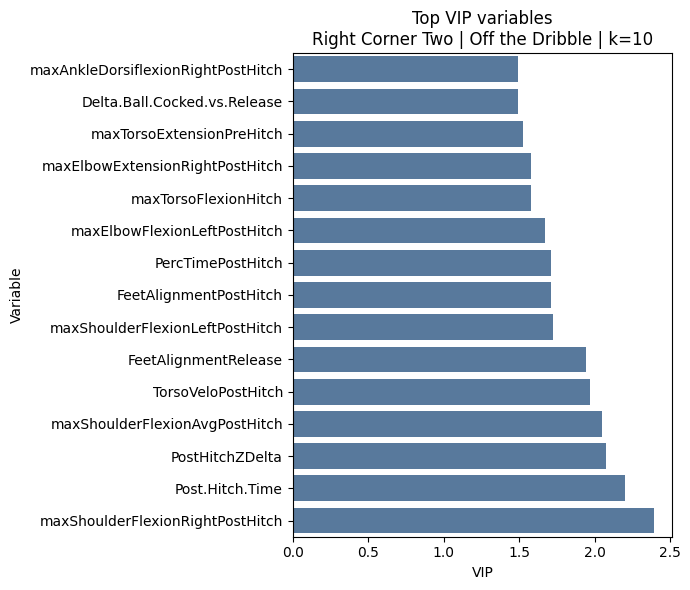

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderFlexionRightPostHitch,0.126441,0.126441
1,TorsoVeloRelease,0.121958,-0.121958
2,maxShoulderFlexionAvgPostHitch,0.121061,0.121061
3,Post.Hitch.Time,0.115476,0.115476
4,HipAlignmentRelease,0.111266,-0.111266
5,maxShoulderFlexionLeftPostHitch,0.109173,0.109173
6,maxHipExtensionAvgPreHitch,0.105986,-0.105986
7,timeToMaxElbowExtensionRightPostHitch,0.102515,0.102515
8,ShoulderTotalROMLeft,0.102293,0.102293
9,timeToMaxShoulderFlexionRightPostHitch,0.102255,0.102255


- **PLS2**

,feature,abs_weight,PLS2
0,maxShoulderFlexionRightPostHitch,0.211908,0.211908
1,Post.Hitch.Time,0.209911,0.209911
2,PostHitchZDelta,0.206458,0.206458
3,TorsoVeloPostHitch,0.180233,0.180233
4,maxShoulderFlexionAvgPostHitch,0.177602,0.177602
5,PercTimePostHitch,0.159943,0.159943
6,maxElbowFlexionLeftPostHitch,0.153967,0.153967
7,maxAnkleDorsiflexionRightPostHitch,0.146856,0.146856
8,maxAnklePlantarflexionRightHitch,0.145463,0.145463
9,maxTorsoExtensionPreHitch,0.145420,-0.145420


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS2,0.483232,0.483232,6.458464
1,PLS1,0.346461,0.346461,85.617106
2,PLS3,-0.243346,0.243346,12.118313
3,PLS4,-0.235024,0.235024,6.776201
4,PLS5,-0.223842,0.223842,4.272479
5,PLS13,0.215344,0.215344,1.115051
6,PLS9,0.205933,0.205933,7.689105
7,PLS6,-0.186600,0.186600,15.282193
8,PLS17,-0.181896,0.181896,0.933764
9,PLS10,0.180844,0.180844,2.022603


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_two__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_two__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
FeetAlignmentRelease,2.181181
maxShoulderFlexionRightPostHitch,2.088246
Post.Hitch.Time,1.943617
FeetAlignmentHitch,1.879970
TorsoVeloPostHitch,1.810364
PostHitchZDelta,1.783607
maxShoulderFlexionAvgPostHitch,1.754945
FeetAlignmentPostHitch,1.671651
maxElbowFlexionAvgHitch,1.627625
maxElbowFlexionLeftPostHitch,1.549799


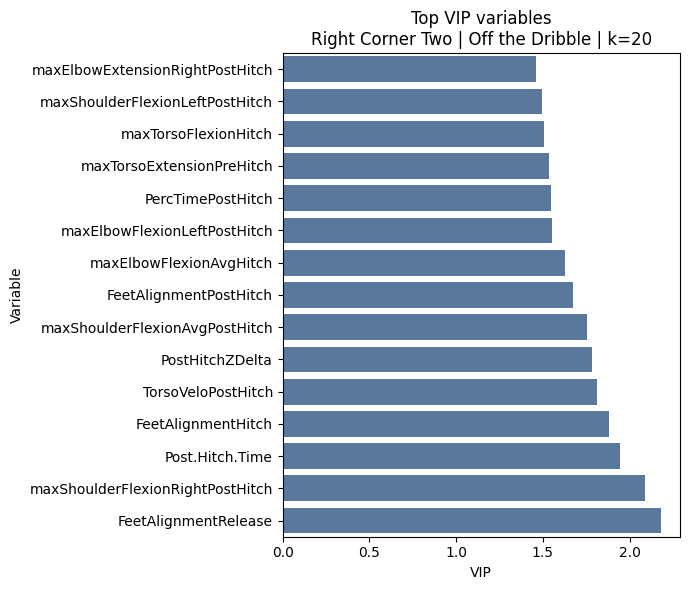

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderFlexionRightPostHitch,0.126441,0.126441
1,TorsoVeloRelease,0.121958,-0.121958
2,maxShoulderFlexionAvgPostHitch,0.121061,0.121061
3,Post.Hitch.Time,0.115476,0.115476
4,HipAlignmentRelease,0.111266,-0.111266
5,maxShoulderFlexionLeftPostHitch,0.109173,0.109173
6,maxHipExtensionAvgPreHitch,0.105986,-0.105986
7,timeToMaxElbowExtensionRightPostHitch,0.102515,0.102515
8,ShoulderTotalROMLeft,0.102293,0.102293
9,timeToMaxShoulderFlexionRightPostHitch,0.102255,0.102255


- **PLS2**

,feature,abs_weight,PLS2
0,maxShoulderFlexionRightPostHitch,0.211908,0.211908
1,Post.Hitch.Time,0.209911,0.209911
2,PostHitchZDelta,0.206458,0.206458
3,TorsoVeloPostHitch,0.180233,0.180233
4,maxShoulderFlexionAvgPostHitch,0.177602,0.177602
5,PercTimePostHitch,0.159943,0.159943
6,maxElbowFlexionLeftPostHitch,0.153967,0.153967
7,maxAnkleDorsiflexionRightPostHitch,0.146856,0.146856
8,maxAnklePlantarflexionRightHitch,0.145463,0.145463
9,maxTorsoExtensionPreHitch,0.145420,-0.145420


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.333624,0.333624,60.082902
1,PLS4,0.282363,0.282363,5.698988
2,PLS5,-0.228057,0.228057,7.325246
3,PLS2,0.218931,0.218931,17.476183
4,PLS7,-0.216736,0.216736,3.278452
5,PLS6,-0.204661,0.204661,5.899234
6,PLS10,-0.187255,0.187255,1.703346
7,PLS8,0.185373,0.185373,4.165460
8,PLS9,0.178901,0.178901,4.923637
9,PLS3,0.124914,0.124914,29.099223


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_two__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_two__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.941226
BallVeloPostHitch,1.692267
maxTorsoFlexionHitch,1.628406
FeetAlignmentPreHitch,1.582389
ShoulderTotalROMRight,1.527445
maxTorsoExtensionPreHitch,1.504121
maxTorsoFlexionPreHitch,1.428741
PreHitchXDelta,1.420801
maxAnkleDorsiflexionRightPreHitch,1.405841
HipAlignmentPreHitch,1.393537


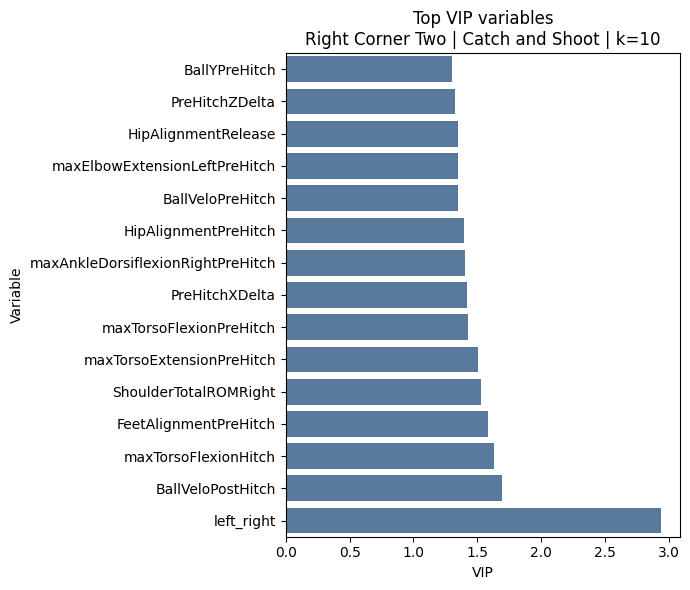

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,hipTotalROMRight,0.113397,0.113397
1,left_right,0.112933,0.112933
2,HipAlignmentRelease,0.111631,-0.111631
3,maxElbowFlexionLeftHitch,0.110094,0.110094
4,ShoulderAlignmentPostHitch,0.108989,-0.108989
5,maxHipFlexionRightPreHitch,0.107089,-0.107089
6,ShoulderAlignmentRelease,0.106228,-0.106228
7,ankleTotalROMAvg,0.106055,0.106055
8,HipAlignmentPostHitch,0.103575,-0.103575
9,Shot.Distance,0.100383,-0.100383


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.184921,0.184921
1,maxTorsoFlexionHitch,0.164614,-0.164614
2,PreHitchYDelta,0.152727,-0.152727
3,BallVeloPostHitch,0.138775,-0.138775
4,HipAlignmentRelease,0.130154,-0.130154
5,FeetAlignmentPostHitch,0.123737,0.123737
6,maxShoulderExtensionLeftPostHitch,0.121775,-0.121775
7,maxElbowFlexionLeftPostHitch,0.118013,0.118013
8,ElbowFlexionAtT0Left,0.116044,0.116044
9,maxTorsoExtensionPreHitch,0.115992,-0.115992


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,0.333624,0.333624,60.082902
1,PLS4,0.282363,0.282363,5.698988
2,PLS12,0.253545,0.253545,0.769888
3,PLS5,-0.228057,0.228057,7.325246
4,PLS2,0.218931,0.218931,17.476183
5,PLS7,-0.216736,0.216736,3.278452
6,PLS6,-0.204661,0.204661,5.899234
7,PLS16,-0.187663,0.187663,0.650951
8,PLS10,-0.187255,0.187255,1.703346
9,PLS14,-0.187211,0.187211,1.869889


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_corner_two__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_corner_two__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.733720
FeetAlignmentPreHitch,1.940115
BallVeloStart,1.724359
BallVeloPostHitch,1.521196
TorsoVeloHitch,1.499573
Pass.Direction,1.484463
maxTorsoFlexionHitch,1.457591
maxElbowExtensionRightPostHitch,1.435804
ShoulderFlexionAtT0Right,1.424436
Shot.Y.Pos,1.423314


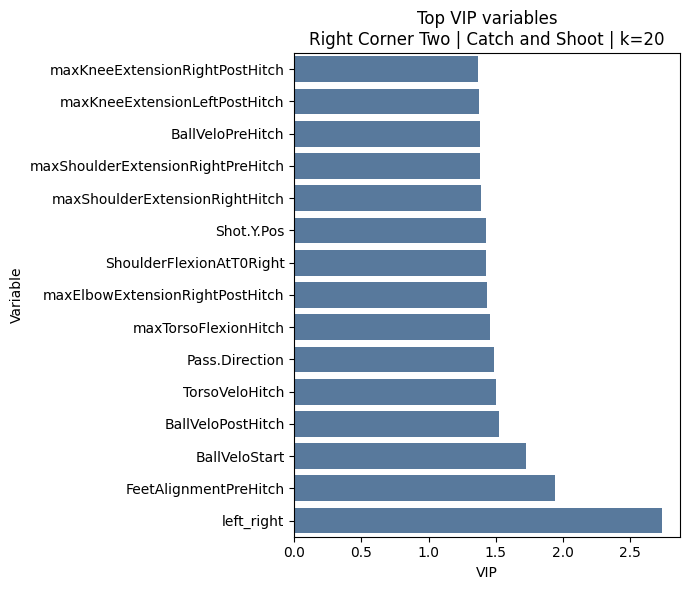

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,hipTotalROMRight,0.113397,0.113397
1,left_right,0.112933,0.112933
2,HipAlignmentRelease,0.111631,-0.111631
3,maxElbowFlexionLeftHitch,0.110094,0.110094
4,ShoulderAlignmentPostHitch,0.108989,-0.108989
5,maxHipFlexionRightPreHitch,0.107089,-0.107089
6,ShoulderAlignmentRelease,0.106228,-0.106228
7,ankleTotalROMAvg,0.106055,0.106055
8,HipAlignmentPostHitch,0.103575,-0.103575
9,Shot.Distance,0.100383,-0.100383


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.184921,0.184921
1,maxTorsoFlexionHitch,0.164614,-0.164614
2,PreHitchYDelta,0.152727,-0.152727
3,BallVeloPostHitch,0.138775,-0.138775
4,HipAlignmentRelease,0.130154,-0.130154
5,FeetAlignmentPostHitch,0.123737,0.123737
6,maxShoulderExtensionLeftPostHitch,0.121775,-0.121775
7,maxElbowFlexionLeftPostHitch,0.118013,0.118013
8,ElbowFlexionAtT0Left,0.116044,0.116044
9,maxTorsoExtensionPreHitch,0.115992,-0.115992


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.212153,0.212153,58.898924
1,PLS5,0.196680,0.196680,4.979457
2,PLS2,0.191740,0.191740,14.802094
3,PLS3,0.184605,0.184605,8.007083
4,PLS6,-0.161903,0.161903,6.841680
5,PLS4,0.160649,0.160649,5.353831
6,PLS10,-0.154059,0.154059,3.967286
7,PLS7,0.151159,0.151159,4.382000
8,PLS9,-0.138829,0.138829,3.478445
9,PLS8,0.136373,0.136373,4.477344


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_three__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_three__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
TorsoVeloPreHitch,1.769756
ShoulderAlignmentPreHitch,1.688581
maxTorsoFlexionHitch,1.657759
maxTorsoExtensionPreHitch,1.504383
maxTorsoFlexionPreHitch,1.459900
timeToMaxHipFlexionRightPreHitch,1.425017
MaxStanceGapRelease,1.421950
MaxBallDist_PreHitch,1.398054
TorsoTotalROMAvg,1.359014
hipTotalROMAvg,1.352348


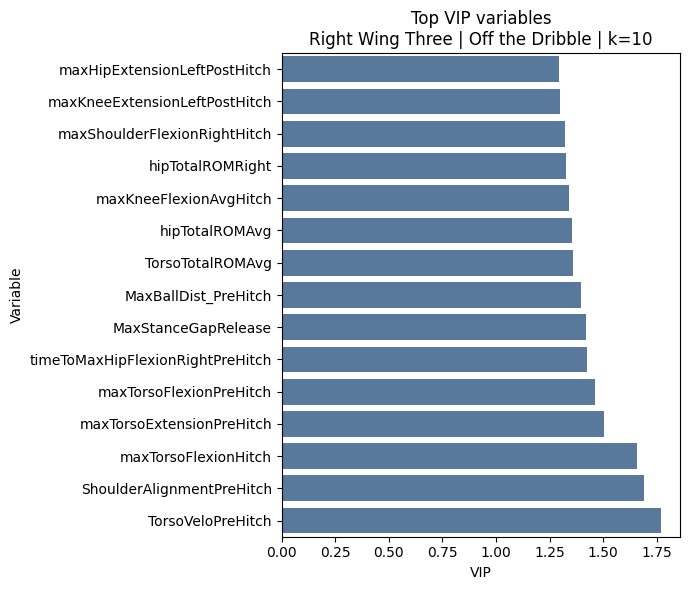

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,KneeTotalROMAvg,0.113954,0.113954
1,hipTotalROMAvg,0.107884,-0.107884
2,timeToMaxHipFlexionRightPreHitch,0.104192,0.104192
3,hipTotalROMLeft,0.099252,-0.099252
4,hipTotalROMRight,0.099108,-0.099108
5,timeToMaxHipExtensionRightPreHitch,0.098775,0.098775
6,timeToMaxShoulderFlexionLeftHitch,0.092223,0.092223
7,maxKneeFlexionRightPreHitch,0.091341,-0.091341
8,BallVeloPostHitch,0.090726,0.090726
9,maxKneeFlexionAvgPreHitch,0.090567,-0.090567


- **PLS2**

,feature,abs_weight,PLS2
0,hipTotalROMAvg,0.162197,0.162197
1,hipTotalROMRight,0.151649,0.151649
2,hipTotalROMLeft,0.146529,0.146529
3,timeAtEndofHitch,0.134758,0.134758
4,timeAtRelease,0.132319,0.132319
5,timeAtStartofHitch,0.130894,0.130894
6,maxHipExtensionAvgPostHitch,0.128477,0.128477
7,KneeTotalROMAvg,0.123638,-0.123638
8,maxHipExtensionLeftPostHitch,0.123632,0.123632
9,maxKneeExtensionLeftPostHitch,0.122307,-0.122307


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.212153,0.212153,58.898924
1,PLS5,0.196680,0.196680,4.979457
2,PLS2,0.191740,0.191740,14.802094
3,PLS3,0.184605,0.184605,8.007083
4,PLS6,-0.161903,0.161903,6.841680
5,PLS4,0.160649,0.160649,5.353831
6,PLS10,-0.154059,0.154059,3.967286
7,PLS7,0.151159,0.151159,4.382000
8,PLS11,-0.140335,0.140335,3.177742
9,PLS9,-0.138829,0.138829,3.478445


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_three__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_three__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
TorsoVeloPreHitch,1.636871
Max.Ball.Cocked,1.590956
ShoulderAlignmentPreHitch,1.517534
maxTorsoFlexionHitch,1.509196
maxTorsoExtensionPreHitch,1.459042
MaxBallDist_PreHitch,1.441385
Max.Ball.Released..Away.from.body.,1.359529
MaxStanceGapRelease,1.330311
Initial.Ball.Velocity,1.300718
ShoulderFlexionAtT0Right,1.295218


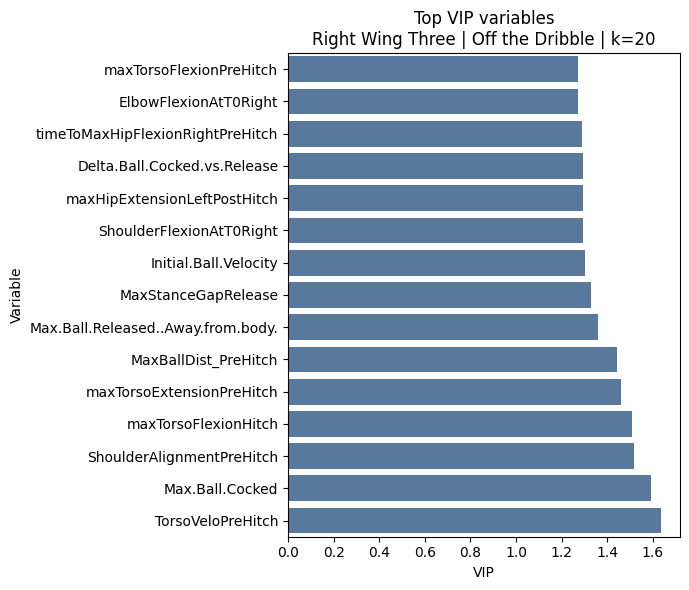

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,KneeTotalROMAvg,0.113954,0.113954
1,hipTotalROMAvg,0.107884,-0.107884
2,timeToMaxHipFlexionRightPreHitch,0.104192,0.104192
3,hipTotalROMLeft,0.099252,-0.099252
4,hipTotalROMRight,0.099108,-0.099108
5,timeToMaxHipExtensionRightPreHitch,0.098775,0.098775
6,timeToMaxShoulderFlexionLeftHitch,0.092223,0.092223
7,maxKneeFlexionRightPreHitch,0.091341,-0.091341
8,BallVeloPostHitch,0.090726,0.090726
9,maxKneeFlexionAvgPreHitch,0.090567,-0.090567


- **PLS2**

,feature,abs_weight,PLS2
0,hipTotalROMAvg,0.162197,0.162197
1,hipTotalROMRight,0.151649,0.151649
2,hipTotalROMLeft,0.146529,0.146529
3,timeAtEndofHitch,0.134758,0.134758
4,timeAtRelease,0.132319,0.132319
5,timeAtStartofHitch,0.130894,0.130894
6,maxHipExtensionAvgPostHitch,0.128477,0.128477
7,KneeTotalROMAvg,0.123638,-0.123638
8,maxHipExtensionLeftPostHitch,0.123632,0.123632
9,maxKneeExtensionLeftPostHitch,0.122307,-0.122307


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS2,0.165580,0.165580,20.886074
1,PLS3,-0.126598,0.126598,9.254187
2,PLS4,-0.119362,0.119362,4.464566
3,PLS1,0.118628,0.118628,34.268841
4,PLS5,0.113052,0.113052,5.761572
5,PLS8,-0.094680,0.094680,2.401578
6,PLS7,0.093399,0.093399,4.144861
7,PLS6,0.087787,0.087787,9.553718
8,PLS9,-0.084638,0.084638,2.206855
9,PLS10,-0.067559,0.067559,6.924854


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_three__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_three__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
BallVeloStart,1.960268
FeetAlignmentPostHitch,1.663516
left_right,1.643240
maxAnklePlantarflexionAvgPostHitch,1.555147
maxShoulderExtensionRightHitch,1.540315
maxShoulderFlexionRightPreHitch,1.475837
maxAnklePlantarflexionRightPostHitch,1.462723
maxShoulderExtensionRightPostHitch,1.435200
maxShoulderExtensionAvgHitch,1.414456
maxShoulderFlexionAvgPreHitch,1.400728


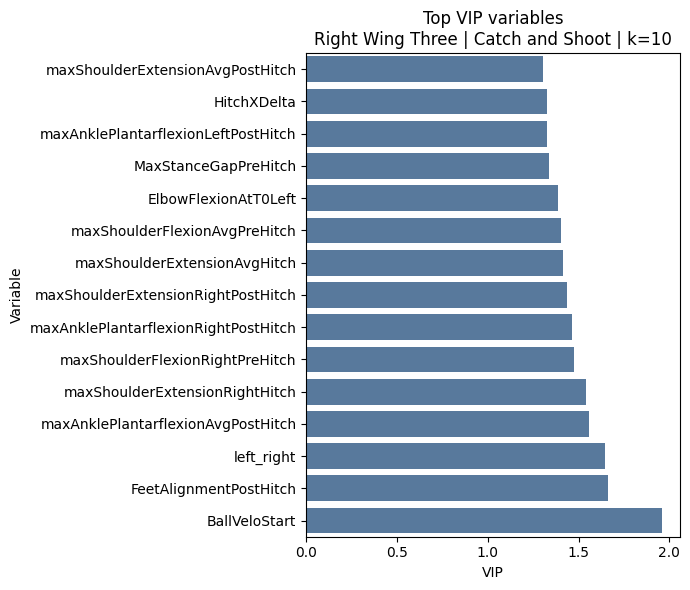

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderExtensionRightHitch,0.160055,0.160055
1,maxShoulderFlexionRightPreHitch,0.152366,0.152366
2,maxAnklePlantarflexionRightPostHitch,0.146957,-0.146957
3,ElbowFlexionAtT0Left,0.144352,0.144352
4,maxElbowFlexionRightHitch,0.141675,-0.141675
5,maxElbowExtensionRightHitch,0.137624,-0.137624
6,maxElbowExtensionRightPreHitch,0.136154,-0.136154
7,maxElbowFlexionAvgHitch,0.136134,-0.136134
8,timeAtStartofMovement,0.134839,-0.134839
9,timeAtEndofHitch,0.132250,-0.132250


- **PLS2**

,feature,abs_weight,PLS2
0,maxShoulderExtensionAvgHitch,0.134940,0.134940
1,maxShoulderFlexionAvgPreHitch,0.127591,0.127591
2,maxShoulderExtensionRightHitch,0.119200,0.119200
3,timeToMaxKneeExtensionRightPostHitch,0.117270,-0.117270
4,maxShoulderFlexionRightPreHitch,0.111687,0.111687
5,timeToMaxHipFlexionLeftPreHitch,0.109047,-0.109047
6,timeToMaxElbowFlexionRightPreHitch,0.107051,-0.107051
7,PercTimePreHitch,0.104017,-0.104017
8,maxAnklePlantarflexionRightPostHitch,0.103488,-0.103488
9,timeToMaxAnklePlantarflexionLeftPostHitch,0.103421,-0.103421


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS2,0.165580,0.165580,20.886074
1,PLS3,-0.126598,0.126598,9.254187
2,PLS4,-0.119362,0.119362,4.464566
3,PLS1,0.118628,0.118628,34.268841
4,PLS5,0.113052,0.113052,5.761572
5,PLS8,-0.094680,0.094680,2.401578
6,PLS7,0.093399,0.093399,4.144861
7,PLS11,0.089342,0.089342,2.188046
8,PLS6,0.087787,0.087787,9.553718
9,PLS9,-0.084638,0.084638,2.206855


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_three__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_three__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
BallVeloStart,1.963383
left_right,1.499537
FeetAlignmentPostHitch,1.481575
ElbowFlexionAtT0Left,1.456304
timeAtEndofHitch,1.418157
timeAtStartofHitch,1.412570
maxShoulderFlexionRightPreHitch,1.407909
maxShoulderExtensionRightHitch,1.401565
timeAtRelease,1.397113
ShoulderAlignmentHitch,1.389508


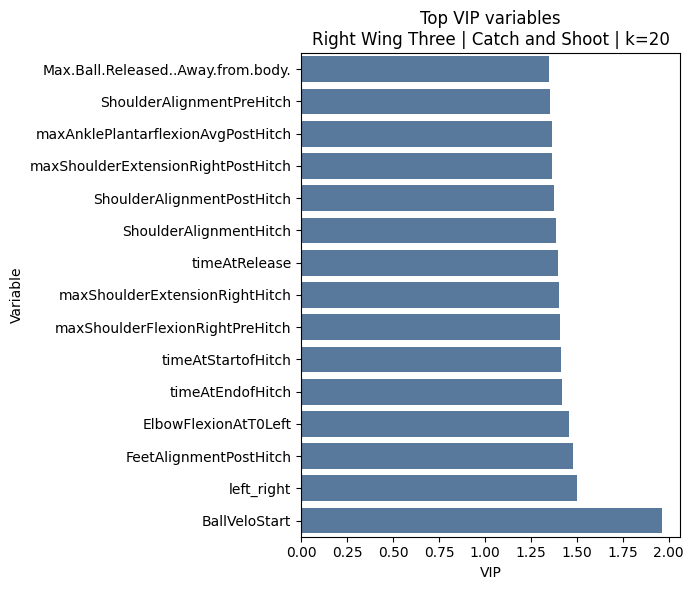

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,maxShoulderExtensionRightHitch,0.160055,0.160055
1,maxShoulderFlexionRightPreHitch,0.152366,0.152366
2,maxAnklePlantarflexionRightPostHitch,0.146957,-0.146957
3,ElbowFlexionAtT0Left,0.144352,0.144352
4,maxElbowFlexionRightHitch,0.141675,-0.141675
5,maxElbowExtensionRightHitch,0.137624,-0.137624
6,maxElbowExtensionRightPreHitch,0.136154,-0.136154
7,maxElbowFlexionAvgHitch,0.136134,-0.136134
8,timeAtStartofMovement,0.134839,-0.134839
9,timeAtEndofHitch,0.132250,-0.132250


- **PLS2**

,feature,abs_weight,PLS2
0,maxShoulderExtensionAvgHitch,0.134940,0.134940
1,maxShoulderFlexionAvgPreHitch,0.127591,0.127591
2,maxShoulderExtensionRightHitch,0.119200,0.119200
3,timeToMaxKneeExtensionRightPostHitch,0.117270,-0.117270
4,maxShoulderFlexionRightPreHitch,0.111687,0.111687
5,timeToMaxHipFlexionLeftPreHitch,0.109047,-0.109047
6,timeToMaxElbowFlexionRightPreHitch,0.107051,-0.107051
7,PercTimePreHitch,0.104017,-0.104017
8,maxAnklePlantarflexionRightPostHitch,0.103488,-0.103488
9,timeToMaxAnklePlantarflexionLeftPostHitch,0.103421,-0.103421


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.634994,0.634994,20.086800
1,PLS3,0.455809,0.455809,15.292264
2,PLS2,-0.419343,0.419343,42.857370
3,PLS4,-0.357319,0.357319,11.898075
4,PLS5,-0.208658,0.208658,7.182233
5,PLS6,-0.126219,0.126219,11.280357
6,PLS7,0.104764,0.104764,11.649146
7,PLS8,0.100500,0.100500,5.806444
8,PLS9,-0.053825,0.053825,6.520103
9,PLS10,0.038162,0.038162,5.494259


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_two__off_the_dribble__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_two__off_the_dribble__k10.csv`

**Top 20 variables by VIP:**

,VIP
BallVeloPostHitch,2.511414
MaxStanceGapRelease,1.850073
maxAnkleDorsiflexionAvgHitch,1.849584
maxAnkleDorsiflexionRightHitch,1.841879
TorsoVeloPostHitch,1.732405
maxElbowFlexionRightPreHitch,1.611773
Initial.Ball.Angle,1.562167
maxAnkleDorsiflexionRightPostHitch,1.510537
maxKneeExtensionRightPostHitch,1.493676
maxElbowExtensionRightHitch,1.492732


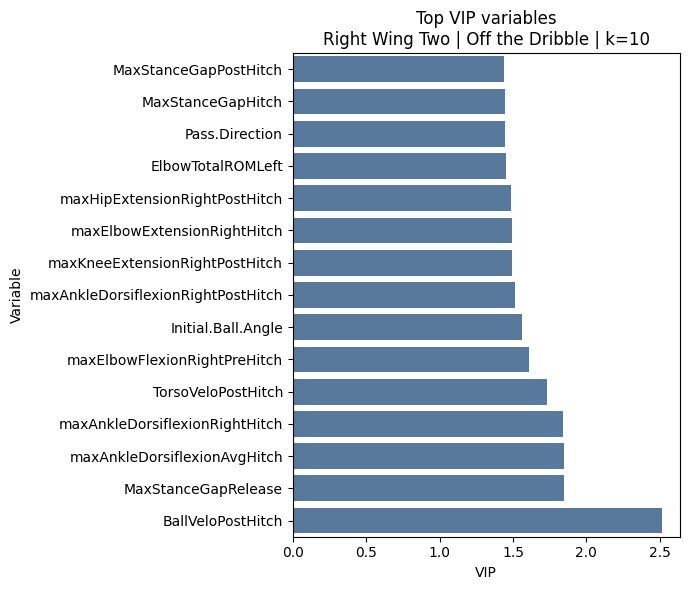

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallVeloPostHitch,0.211247,0.211247
1,maxAnkleDorsiflexionRightHitch,0.164612,0.164612
2,maxAnkleDorsiflexionAvgHitch,0.154657,0.154657
3,maxAnkleDorsiflexionRightPostHitch,0.144947,0.144947
4,TorsoVeloPostHitch,0.144310,0.144310
5,MaxStanceGapHitch,0.136609,0.136609
6,maxKneeExtensionRightPostHitch,0.136290,0.136290
7,MaxStanceGapRelease,0.133079,0.133079
8,maxElbowFlexionRightPreHitch,0.132918,-0.132918
9,ElbowTotalROMLeft,0.132856,-0.132856


- **PLS2**

,feature,abs_weight,PLS2
0,BallVeloPostHitch,0.107839,0.107839
1,MaxStanceGapRelease,0.106946,0.106946
2,PercTimePostHitch,0.106458,-0.106458
3,timeToMaxHipFlexionRightPreHitch,0.103700,0.103700
4,timeToMaxAnklePlantarflexionRightHitch,0.102827,0.102827
5,maxElbowExtensionRightHitch,0.102415,-0.102415
6,FeetAlignmentPreHitch,0.101352,-0.101352
7,Shot.X.Pos,0.101162,-0.101162
8,PostHitchZDelta,0.100201,-0.100201
9,timeToMaxAnklePlantarflexionRightPostHitch,0.099669,0.099669


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.634994,0.634994,20.086800
1,PLS3,0.455809,0.455809,15.292264
2,PLS2,-0.419343,0.419343,42.857370
3,PLS4,-0.357319,0.357319,11.898075
4,PLS5,-0.208658,0.208658,7.182233
5,PLS6,-0.126219,0.126219,11.280357
6,PLS7,0.104764,0.104764,11.649146
7,PLS8,0.100500,0.100500,5.806444
8,PLS9,-0.053825,0.053825,6.520103
9,PLS10,0.038162,0.038162,5.494259


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_two__off_the_dribble__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_two__off_the_dribble__k20.csv`

**Top 20 variables by VIP:**

,VIP
BallVeloPostHitch,2.510896
MaxStanceGapRelease,1.849732
maxAnkleDorsiflexionAvgHitch,1.849100
maxAnkleDorsiflexionRightHitch,1.841639
TorsoVeloPostHitch,1.732014
maxElbowFlexionRightPreHitch,1.611663
Initial.Ball.Angle,1.561738
maxAnkleDorsiflexionRightPostHitch,1.510247
maxKneeExtensionRightPostHitch,1.493477
maxElbowExtensionRightHitch,1.492529


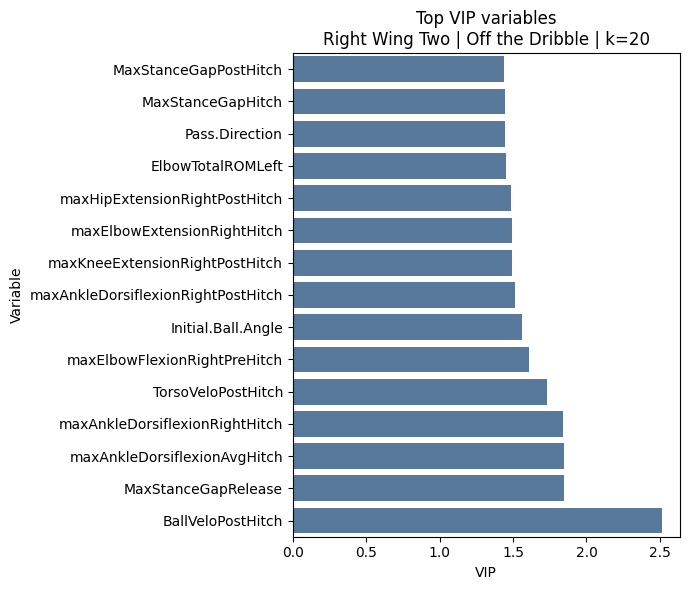

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallVeloPostHitch,0.211247,0.211247
1,maxAnkleDorsiflexionRightHitch,0.164612,0.164612
2,maxAnkleDorsiflexionAvgHitch,0.154657,0.154657
3,maxAnkleDorsiflexionRightPostHitch,0.144947,0.144947
4,TorsoVeloPostHitch,0.144310,0.144310
5,MaxStanceGapHitch,0.136609,0.136609
6,maxKneeExtensionRightPostHitch,0.136290,0.136290
7,MaxStanceGapRelease,0.133079,0.133079
8,maxElbowFlexionRightPreHitch,0.132918,-0.132918
9,ElbowTotalROMLeft,0.132856,-0.132856


- **PLS2**

,feature,abs_weight,PLS2
0,BallVeloPostHitch,0.107839,0.107839
1,MaxStanceGapRelease,0.106946,0.106946
2,PercTimePostHitch,0.106458,-0.106458
3,timeToMaxHipFlexionRightPreHitch,0.103700,0.103700
4,timeToMaxAnklePlantarflexionRightHitch,0.102827,0.102827
5,maxElbowExtensionRightHitch,0.102415,-0.102415
6,FeetAlignmentPreHitch,0.101352,-0.101352
7,Shot.X.Pos,0.101162,-0.101162
8,PostHitchZDelta,0.100201,-0.100201
9,timeToMaxAnklePlantarflexionRightPostHitch,0.099669,0.099669


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.480527,0.480527,83.813631
1,PLS4,-0.470682,0.470682,12.458743
2,PLS2,-0.469290,0.469290,21.615912
3,PLS3,0.321096,0.321096,21.907308
4,PLS5,-0.313642,0.313642,4.196915
5,PLS6,-0.199284,0.199284,6.977353
6,PLS7,-0.186732,0.186732,5.160184
7,PLS8,0.154093,0.154093,2.661634
8,PLS9,0.105726,0.105726,1.849988
9,PLS10,0.089715,0.089715,2.232526


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_two__catch_and_shoot__k10.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_two__catch_and_shoot__k10.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.119727
FeetAlignmentPostHitch,2.081403
maxAnkleDorsiflexionAvgHitch,1.810413
ankleTotalROMAvg,1.719465
Pass.Direction,1.647975
Max.Ball.Arc,1.548686
Ball_to_Rim_Angle,1.547075
maxAnkleDorsiflexionRightHitch,1.546152
HipAlignmentPostHitch,1.538559
FeetAlignmentHitch,1.465546


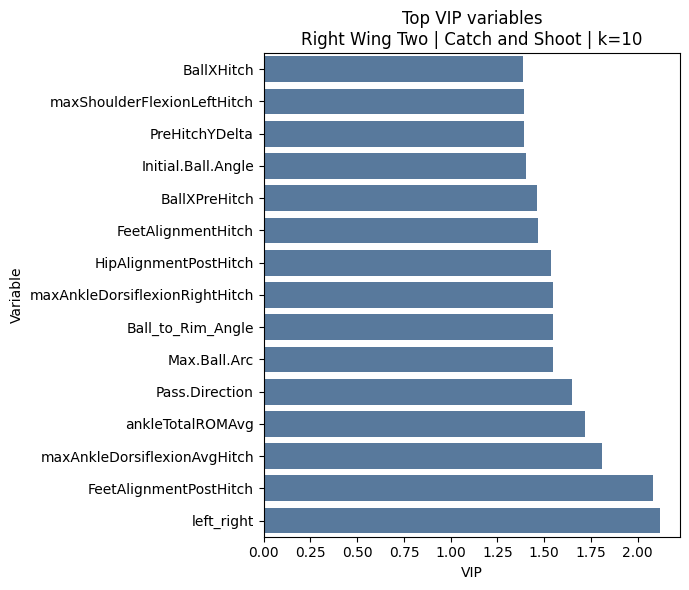

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallXRelease,0.127116,0.127116
1,BallXPostHitch,0.127103,0.127103
2,Shot.X.Pos,0.121921,-0.121921
3,maxElbowExtensionRightPostHitch,0.121903,-0.121903
4,BallXHitch,0.119430,0.119430
5,maxAnkleDorsiflexionAvgHitch,0.118984,-0.118984
6,BallXPreHitch,0.118495,0.118495
7,HipAlignmentRelease,0.116778,-0.116778
8,Shot.Distance,0.114079,-0.114079
9,Pass.Direction,0.114001,-0.114001


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.208637,0.208637
1,Ball_to_Rim_Angle,0.170388,-0.170388
2,HipAlignmentPostHitch,0.154263,0.154263
3,maxKneeFlexionLeftHitch,0.139021,0.139021
4,maxAnkleDorsiflexionAvgHitch,0.136723,-0.136723
5,Max.Ball.Arc,0.131973,-0.131973
6,BallXPreHitch,0.125982,0.125982
7,hipTotalROMRight,0.124026,0.124026
8,MaxBallDist_PostHitch,0.123881,0.123881
9,maxElbowFlexionLeftHitch,0.117058,-0.117058


...

,component,corr_with_made,abs_corr_with_made,score_variance
0,PLS1,-0.480527,0.480527,83.813631
1,PLS4,-0.470682,0.470682,12.458743
2,PLS2,-0.469290,0.469290,21.615912
3,PLS3,0.321096,0.321096,21.907308
4,PLS5,-0.313642,0.313642,4.196915
5,PLS6,-0.199284,0.199284,6.977353
6,PLS7,-0.186732,0.186732,5.160184
7,PLS8,0.154093,0.154093,2.661634
8,PLS9,0.105726,0.105726,1.849988
9,PLS10,0.089715,0.089715,2.232526


**Component definitions (exact weights) saved:** `outputs\pls_definition__right_wing_two__catch_and_shoot__k20.csv`

**VIP scores saved:** `outputs\pls_vip__right_wing_two__catch_and_shoot__k20.csv`

**Top 20 variables by VIP:**

,VIP
left_right,2.118624
FeetAlignmentPostHitch,2.084957
maxAnkleDorsiflexionAvgHitch,1.809067
ankleTotalROMAvg,1.727418
Pass.Direction,1.648761
Max.Ball.Arc,1.553984
maxAnkleDorsiflexionRightHitch,1.553559
Ball_to_Rim_Angle,1.541814
HipAlignmentPostHitch,1.534790
FeetAlignmentHitch,1.480983


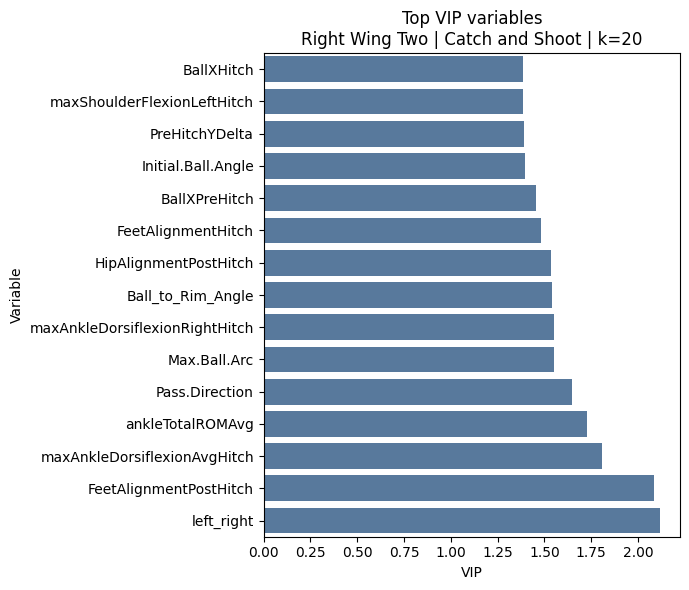

**Component makeup (preview): top contributors for PLS1–PLS3 by |weight|**

- **PLS1**

,feature,abs_weight,PLS1
0,BallXRelease,0.127116,0.127116
1,BallXPostHitch,0.127103,0.127103
2,Shot.X.Pos,0.121921,-0.121921
3,maxElbowExtensionRightPostHitch,0.121903,-0.121903
4,BallXHitch,0.119430,0.119430
5,maxAnkleDorsiflexionAvgHitch,0.118984,-0.118984
6,BallXPreHitch,0.118495,0.118495
7,HipAlignmentRelease,0.116778,-0.116778
8,Shot.Distance,0.114079,-0.114079
9,Pass.Direction,0.114001,-0.114001


- **PLS2**

,feature,abs_weight,PLS2
0,left_right,0.208637,0.208637
1,Ball_to_Rim_Angle,0.170388,-0.170388
2,HipAlignmentPostHitch,0.154263,0.154263
3,maxKneeFlexionLeftHitch,0.139021,0.139021
4,maxAnkleDorsiflexionAvgHitch,0.136723,-0.136723
5,Max.Ball.Arc,0.131973,-0.131973
6,BallXPreHitch,0.125982,0.125982
7,hipTotalROMRight,0.124026,0.124026
8,MaxBallDist_PostHitch,0.123881,0.123881
9,maxElbowFlexionLeftHitch,0.117058,-0.117058


...

**Saved CV performance summary:** `outputs\pls_cv_performance_summary.csv`

# Cross-Section Visualizations

These plots use VIP as a proxy for contribution. Treat “significant” as **consistently high VIP across subsets**.

## VIP summary (k=10)

,mean_VIP
left_right,1.586781
Shot.Distance,1.246604
MaxStanceGapPostHitch,1.223678
TorsoVeloPostHitch,1.203641
MaxStanceGapRelease,1.196369
Shot.X.Pos,1.184982
Max.Ball.Arc,1.175923
maxTorsoFlexionHitch,1.173636
maxAnkleDorsiflexionRightHitch,1.155839
MaxStanceGapPreHitch,1.155061


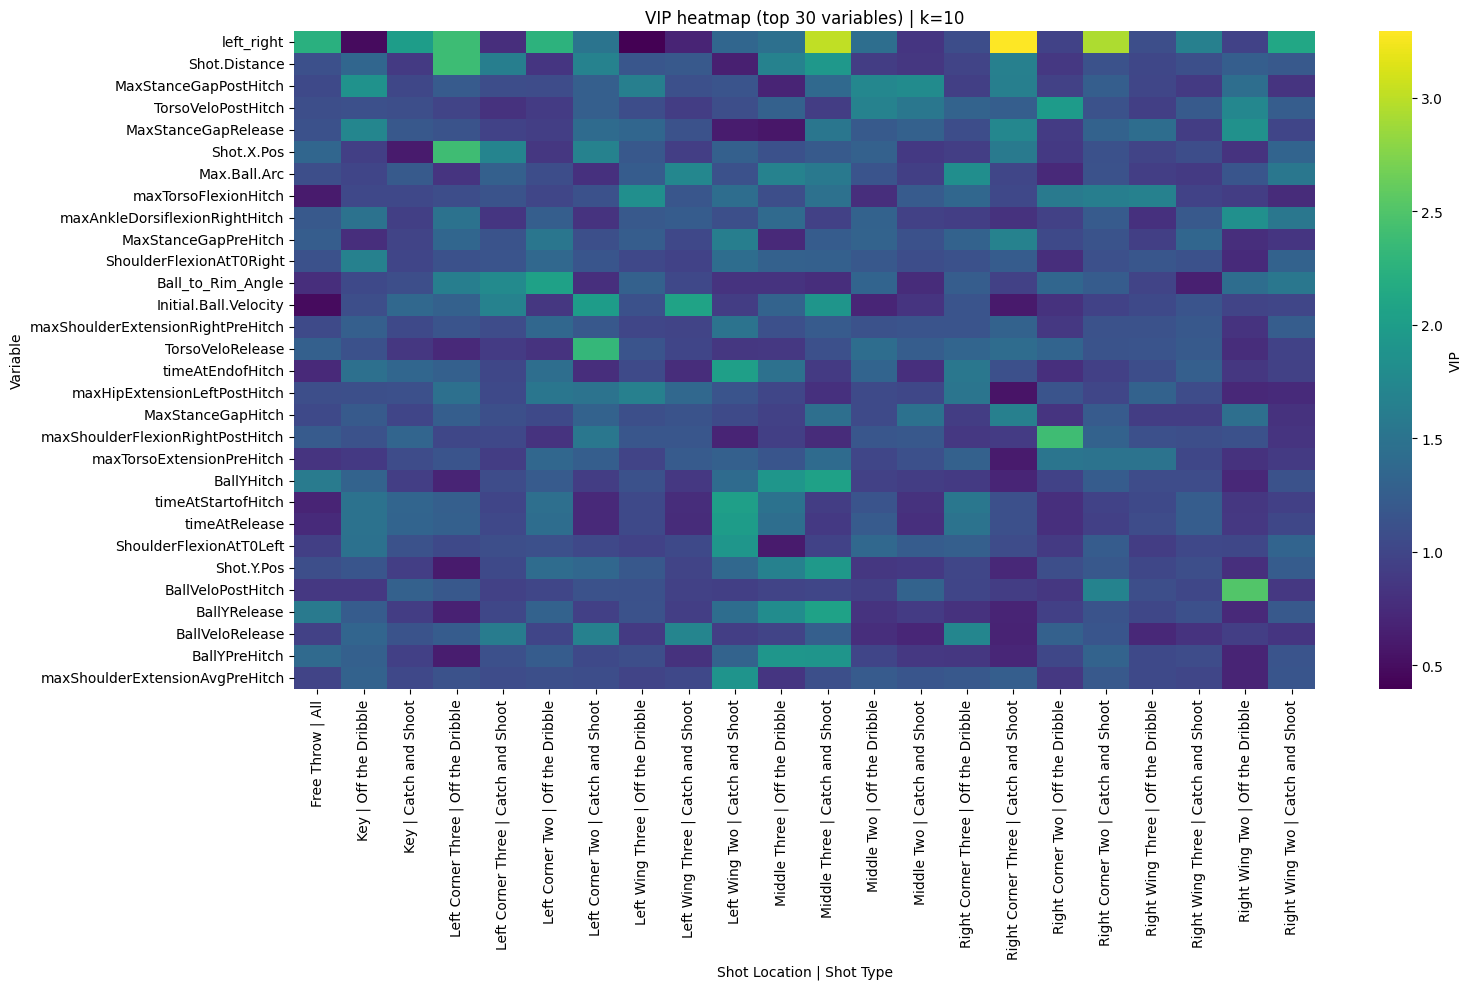

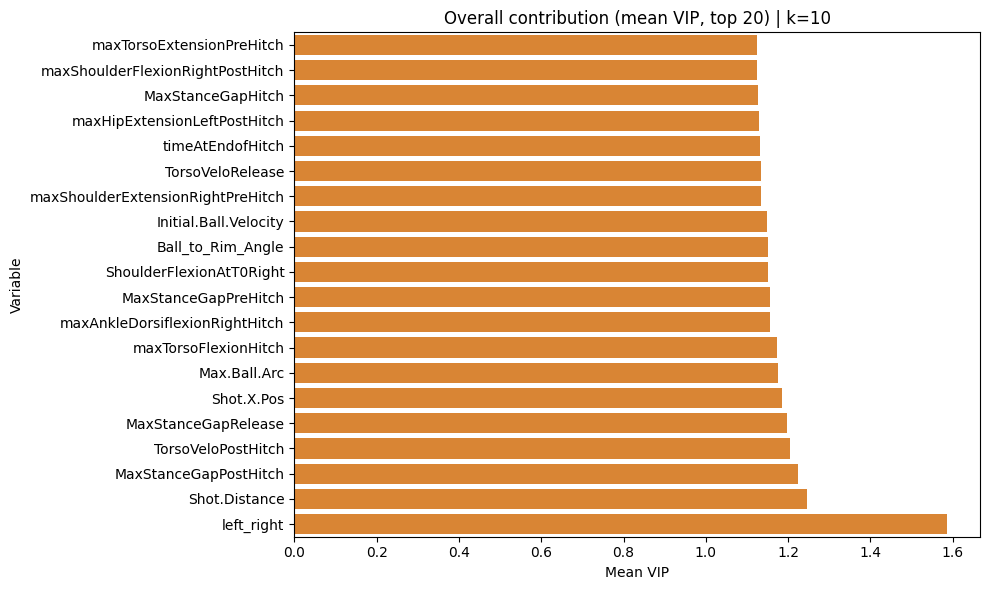

## VIP summary (k=20)

,mean_VIP
left_right,1.667124
Max.Ball.Arc,1.270617
MaxStanceGapPostHitch,1.248106
MaxStanceGapRelease,1.243801
Shot.Distance,1.232357
timeAtEndofHitch,1.231906
timeAtStartofHitch,1.227937
FeetAlignmentHitch,1.221268
timeAtRelease,1.219315
Shot.X.Pos,1.217569


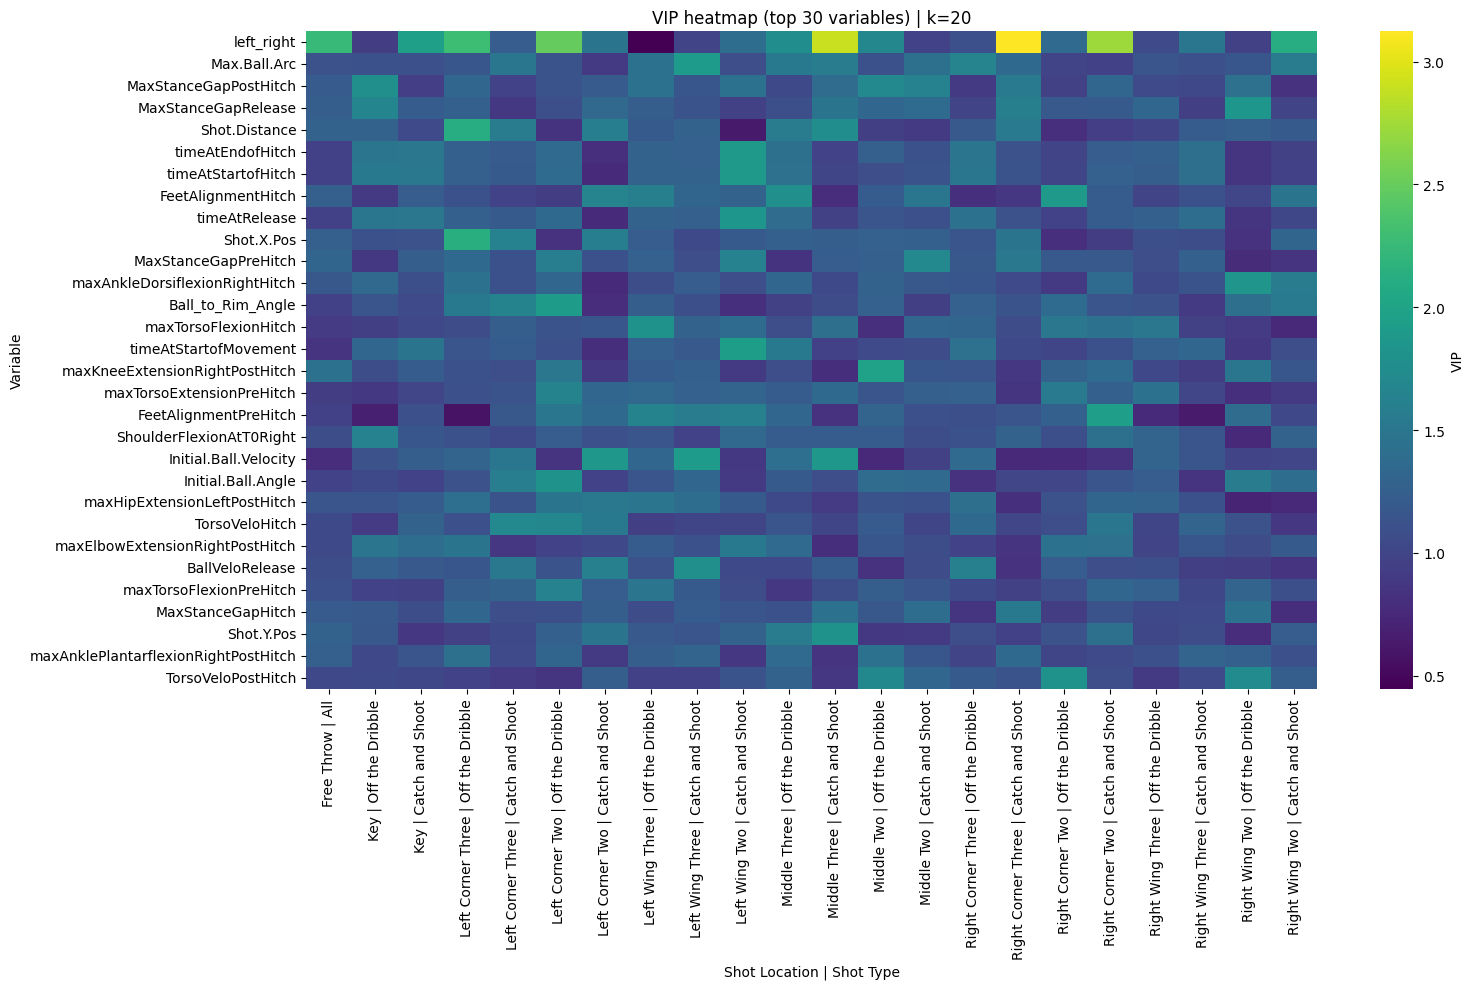

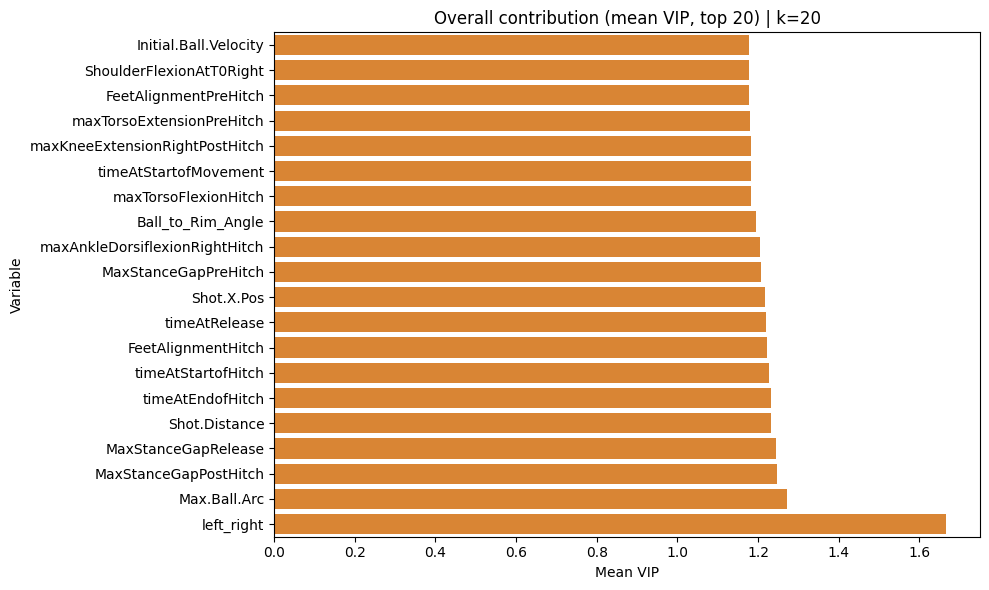

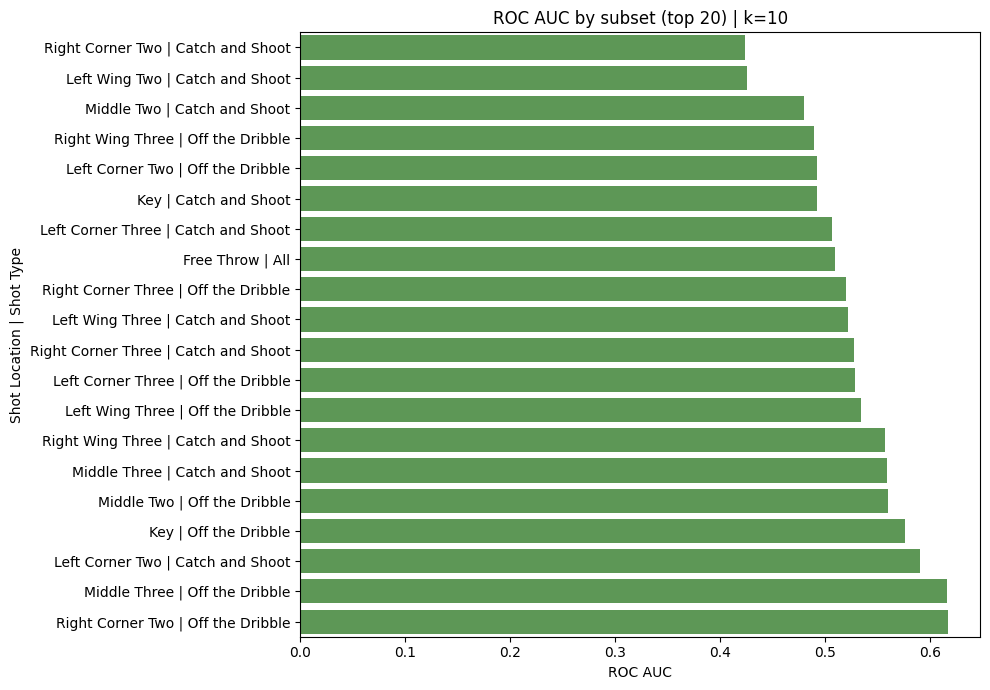

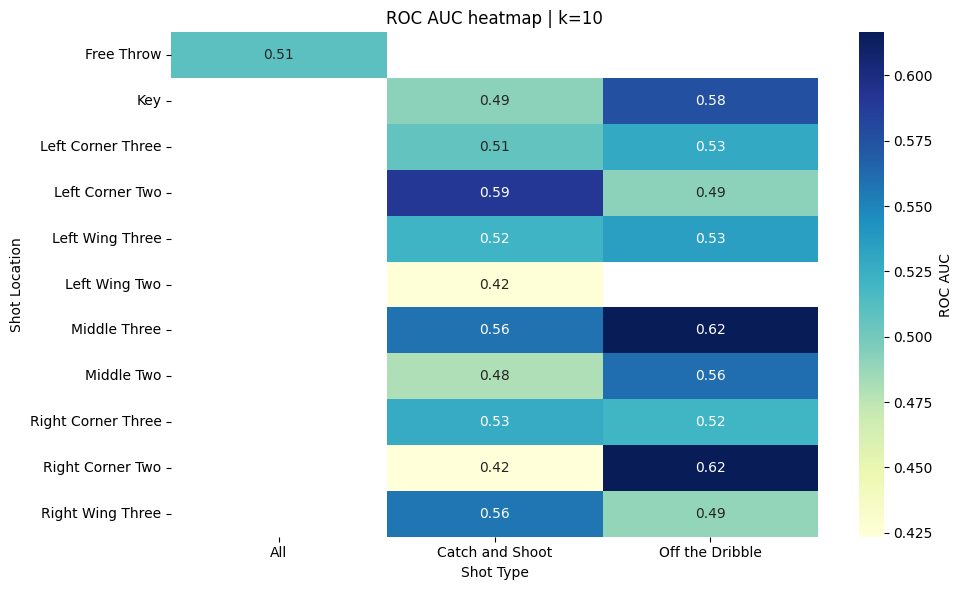

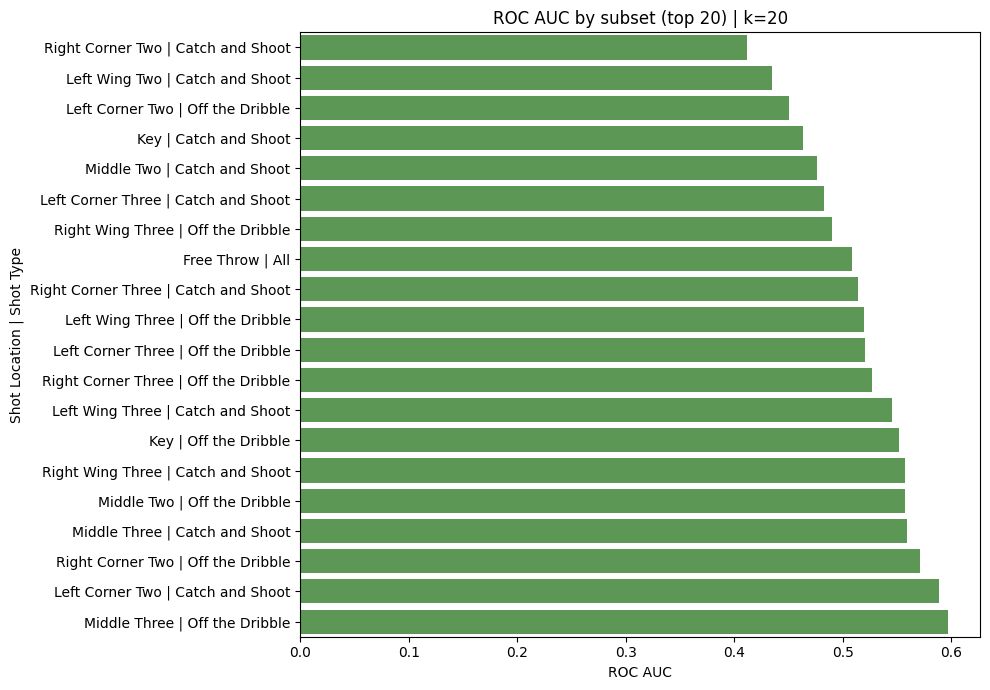

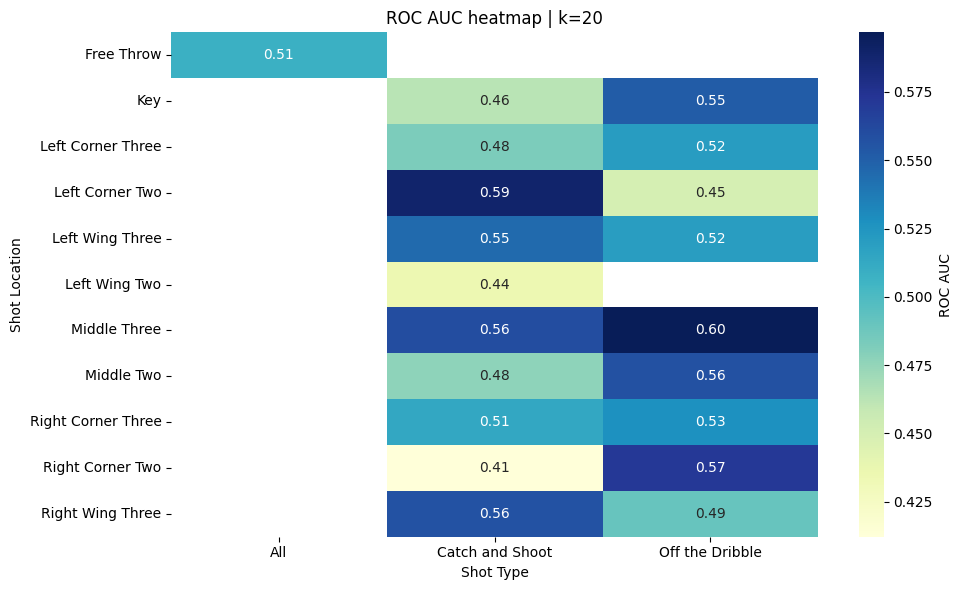


Outputs saved under: outputs


In [16]:
results = pra.run_pls_analysis(
    data_path=DATA_PATH,
    min_shots_per_player=MIN_SHOTS_PER_PLAYER,
    n_components_requested=N_COMPONENTS,
    run_cv_eval=RUN_CV_EVAL,
    cv_max_splits=CV_MAX_SPLITS,
    cv_mode=CV_MODE,
    exclude_norm_keys=EXCLUDE_NORM_KEYS,
    output_dir=OUTPUT_DIR,
)

pra.cross_section_plots(results, n_components_requested=N_COMPONENTS)

print("\nOutputs saved under:", results["output_dir"])